
# Home Credit Default Risk

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

from pathlib import Path
from tkinter import Tk
from tkinter.filedialog import askdirectory

## Load Datasets

In [3]:
data_path = Path('../home_credit_data')
if not data_path.exists():
    root = Tk()
    root.withdraw()
    data_path= Path(askdirectory(title='Select the folder with the data(csv_files)'))

In [ ]:

train = pd.read_csv(data_path/'application_train.csv')
test = pd.read_csv(data_path/'application_test.csv')
bureau = pd.read_csv(data_path/'bureau.csv')
bureau_balance = pd.read_csv(data_path/'bureau_balance.csv')
credit_card = pd.read_csv(data_path/'credit_card_balance.csv')
installments = pd.read_csv(data_path/'installments_payments.csv')
pos_cash = pd.read_csv(data_path/'POS_CASH_balance.csv')
previous = pd.read_csv(data_path/'previous_application.csv')


## Basic Exploration

In [4]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 150)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_colwidth', 1000)

In [5]:

dfs = {
    'Application_train': train,
    'Application_test': test,
    'bureau_balance': bureau_balance,
    'bureau': bureau,
    'credit_card_balance': credit_card,
    'installments_payments': installments,
    'POS_CASH_balance': pos_cash,
    'previous_application': previous
}
for name, df in dfs.items():
    print(f"\n📊 Dataset:{name}")
    print(f"Shape: {df.shape}")
    print(f"\nFirst 5 rows:")
    print(df.head())
    print(f"\nColumns:")
    print(df.columns)
    print(f"*========================================================================================================================================================================================*")


📊 Dataset:Application_train
Shape: (307511, 122)

First 5 rows:
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE NAME_TYPE_SUITE NAME_INCOME_TYPE            NAME_EDUCATION_TYPE    NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  OWN_CAR_AGE  FLAG_MOBIL  FLAG_EMP_PHONE  FLAG_WORK_PHONE  FLAG_CONT_MOBILE  FLAG_PHONE  FLAG_EMAIL OCCUPATION_TYPE  CNT_FAM_MEMBERS  REGION_RATING_CLIENT  REGION_RATING_CLIENT_W_CITY WEEKDAY_APPR_PROCESS_START  HOUR_APPR_PROCESS_START  REG_REGION_NOT_LIVE_REGION  REG_REGION_NOT_WORK_REGION  LIVE_REGION_NOT_WORK_REGION  REG_CITY_NOT_LIVE_CITY  REG_CITY_NOT_WORK_CITY  LIVE_CITY_NOT_WORK_CITY       ORGANIZATION_TYPE  EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  APARTMENTS_AVG  BASEMENTAREA_AVG  YEARS_BEGINEXPLUATATION_AVG  YEARS_BUILD_AVG  COMMONAREA_AVG  ELEVATORS_AVG  ENTRANCES_A

In [6]:
credit_card.sort_values(by='AMT_PAYMENT_CURRENT',ascending=True).head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
3840282,2208658,330072,-8,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,5.00,Active,0,0
3582086,1874725,319877,-67,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,23.00,Active,0,0
2960066,2725991,358992,-15,0.00,135000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,70.00,Completed,0,0
2205770,2270955,123207,-17,67.50,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,67.50,67.50,0.00,0,0.00,0.00,33.00,Active,1431,0
637085,2586329,328286,-13,0.00,135000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,55.00,Completed,0,0


## Missing Value Analysis

In [7]:
rows = []
for name, df in dfs.items():
    rows.append({
        "Table":            name,
        "Rows":             f"{df.shape[0]:,}",
        "Columns":          df.shape[1],
        "Numeric Cols":     df.select_dtypes(include=np.number).shape[1],
        "Categorical Cols": df.select_dtypes(include="object").shape[1],
        "Avg Missing %":    round(df.isnull().mean().mean() * 100, 2),
    })

overview_df = pd.DataFrame(rows)
display(overview_df.style
    .set_caption("All Dataset Tables Summary")
    .background_gradient(subset=["Avg Missing %"], cmap="Reds")
    .format({'Avg Missing %': '{:.2f}%'})
    .set_properties(**{"text-align": "center"})
)

,Table,Rows,Columns,Numeric Cols,Categorical Cols,Avg Missing %
0,Application_train,"307,511",122,106,16,24.40%
1,Application_test,"48,744",121,105,16,23.81%
2,bureau_balance,"27,299,925",3,2,1,0.00%
3,bureau,"1,716,428",17,14,3,13.50%
4,credit_card_balance,"3,840,312",23,22,1,6.65%
5,installments_payments,"13,605,401",8,8,0,0.01%
6,POS_CASH_balance,"10,001,358",8,7,1,0.07%
7,previous_application,"1,670,214",37,21,16,17.98%


In [8]:
for name, df in dfs.items():

    missing = (df.isnull().sum() / len(df)) * 100
    missing = missing[missing > 0].sort_values(ascending=False)

    if len(missing) > 0:

        missing_df = missing.reset_index()
        missing_df.columns = ['Column', 'Missing %']

        print(f'\n{name.upper()} Missing Values')

        display(
            missing_df.head(20).style
            .background_gradient(cmap='Reds', subset=['Missing %'])
            .format({'Missing %': '{:.2f}%'})
            .set_properties(**{"text-align": "center"})
        )


APPLICATION_TRAIN Missing Values


,Column,Missing %
0,COMMONAREA_MEDI,69.87%
1,COMMONAREA_MODE,69.87%
2,COMMONAREA_AVG,69.87%
3,NONLIVINGAPARTMENTS_MODE,69.43%
4,NONLIVINGAPARTMENTS_MEDI,69.43%
5,NONLIVINGAPARTMENTS_AVG,69.43%
6,FONDKAPREMONT_MODE,68.39%
7,LIVINGAPARTMENTS_AVG,68.35%
8,LIVINGAPARTMENTS_MEDI,68.35%
9,LIVINGAPARTMENTS_MODE,68.35%



APPLICATION_TEST Missing Values


,Column,Missing %
0,COMMONAREA_AVG,68.72%
1,COMMONAREA_MODE,68.72%
2,COMMONAREA_MEDI,68.72%
3,NONLIVINGAPARTMENTS_AVG,68.41%
4,NONLIVINGAPARTMENTS_MODE,68.41%
5,NONLIVINGAPARTMENTS_MEDI,68.41%
6,FONDKAPREMONT_MODE,67.28%
7,LIVINGAPARTMENTS_MODE,67.25%
8,LIVINGAPARTMENTS_AVG,67.25%
9,LIVINGAPARTMENTS_MEDI,67.25%



BUREAU Missing Values


...

,Column,Missing %
0,DAYS_ENTRY_PAYMENT,0.02%
1,AMT_PAYMENT,0.02%



POS_CASH_BALANCE Missing Values


,Column,Missing %
0,CNT_INSTALMENT_FUTURE,0.26%
1,CNT_INSTALMENT,0.26%



PREVIOUS_APPLICATION Missing Values


,Column,Missing %
0,RATE_INTEREST_PRIVILEGED,99.64%
1,RATE_INTEREST_PRIMARY,99.64%
2,AMT_DOWN_PAYMENT,53.64%
3,RATE_DOWN_PAYMENT,53.64%
4,NAME_TYPE_SUITE,49.12%
5,DAYS_LAST_DUE,40.30%
6,DAYS_FIRST_DRAWING,40.30%
7,DAYS_FIRST_DUE,40.30%
8,DAYS_TERMINATION,40.30%
9,NFLAG_INSURED_ON_APPROVAL,40.30%


## Missing value handling 
#### Train dataset

In [9]:
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,351000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,-3648.00,-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,-1134.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,1129500.00,Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,-1186.00,-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,67500.00,135000.00,6750.00,135000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,-4260.00,-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.0

In [10]:
missing_df=(train.isna().mean().mul(100).loc[lambda x: x>0].sort_values(ascending=False)).round(5).reset_index(name='Missing %')
display(
            missing_df.style
            .background_gradient(cmap='Reds', subset=['Missing %'])
            .format({'Missing %': '{:.5f}%'})
            .set_properties(**{"text-align": "center"})
        )

,index,Missing %
0,COMMONAREA_MEDI,69.87230%
1,COMMONAREA_MODE,69.87230%
2,COMMONAREA_AVG,69.87230%
3,NONLIVINGAPARTMENTS_MODE,69.43296%
4,NONLIVINGAPARTMENTS_MEDI,69.43296%
5,NONLIVINGAPARTMENTS_AVG,69.43296%
6,FONDKAPREMONT_MODE,68.38617%
7,LIVINGAPARTMENTS_AVG,68.35495%
8,LIVINGAPARTMENTS_MEDI,68.35495%
9,LIVINGAPARTMENTS_MODE,68.35495%


In [11]:
len((train.isna().mean().mul(100).loc[lambda x: x>0].sort_values(ascending=False)).round(5))

67

In [12]:
drop_cols = [

    # COMMONAREA
    'COMMONAREA_AVG',
    'COMMONAREA_MEDI',
    'COMMONAREA_MODE',

    # NONLIVING APARTMENTS
    'NONLIVINGAPARTMENTS_AVG',
    'NONLIVINGAPARTMENTS_MEDI',
    'NONLIVINGAPARTMENTS_MODE',

    # LIVING APARTMENTS
    'LIVINGAPARTMENTS_AVG',
    'LIVINGAPARTMENTS_MEDI',
    'LIVINGAPARTMENTS_MODE',

    # FLOORSMIN
    'FLOORSMIN_AVG',
    'FLOORSMIN_MEDI',
    'FLOORSMIN_MODE',

    # YEARS BUILD DUPLICATES
    'YEARS_BUILD_MEDI',
    'YEARS_BUILD_MODE',

    # LANDAREA DUPLICATES
    'LANDAREA_MEDI',
    'LANDAREA_MODE',

    # BASEMENT DUPLICATES
    'BASEMENTAREA_MODE',
    'BASEMENTAREA_MEDI',

    # NONLIVINGAREA DUPLICATES
    'NONLIVINGAREA_MEDI',
    'NONLIVINGAREA_MODE',

    # ELEVATOR DUPLICATES
    'ELEVATORS_MEDI',
    'ELEVATORS_MODE',

    # APARTMENT DUPLICATES
    'APARTMENTS_MEDI',
    'APARTMENTS_MODE',

    # ENTRANCES DUPLICATES
    'ENTRANCES_MEDI',
    'ENTRANCES_MODE',

    # LIVINGAREA DUPLICATES
    'LIVINGAREA_MEDI',
    'LIVINGAREA_MODE',

    # FLOORSMAX DUPLICATES
    'FLOORSMAX_MEDI',
    'FLOORSMAX_MODE',

    # YEARS_BEGINEXPLUATATION duplicates
    'YEARS_BEGINEXPLUATATION_MEDI',
    'YEARS_BEGINEXPLUATATION_MODE',

    # cat_col
    'FONDKAPREMONT_MODE'
]
train.drop(columns=drop_cols, inplace=True)

test.drop(columns=drop_cols, inplace=True)

In [13]:
median_cols = [

    'YEARS_BUILD_AVG',
    'LANDAREA_AVG',
    'BASEMENTAREA_AVG',
    'NONLIVINGAREA_AVG',
    'ELEVATORS_AVG',
    'APARTMENTS_AVG',
    'ENTRANCES_AVG',
    'LIVINGAREA_AVG',
    'FLOORSMAX_AVG',
    'YEARS_BEGINEXPLUATATION_AVG',
    'TOTALAREA_MODE',

    'AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR',

    'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE',

    'AMT_GOODS_PRICE',
    'AMT_ANNUITY',
    'DAYS_LAST_PHONE_CHANGE'
]

for df in [train, test]:

    for col in median_cols:

        df[col] = df[col].fillna(
            df[col].median()
        )

In [ ]:
for df in [train, test]:
    df.drop(columns='OWN_CAR_AGE', inplace=True)

## Handle Data Inconsistencies

In [18]:
cat_cols = train.select_dtypes(include='object').columns

for col in cat_cols:
    
    print(f"\n{'='*50}")
    print(f"Column : {col}")
    print(f"{'='*50}")
    
    print(train[col].unique())


Column : NAME_CONTRACT_TYPE
['Cash loans' 'Revolving loans']

Column : CODE_GENDER
['M' 'F' 'XNA']

Column : FLAG_OWN_CAR
['N' 'Y']

Column : FLAG_OWN_REALTY
['Y' 'N']

Column : NAME_TYPE_SUITE
['Unaccompanied' 'Family' 'Spouse, partner' 'Children' 'Other_A' nan
 'Other_B' 'Group of people']

Column : NAME_INCOME_TYPE
['Working' 'State servant' 'Commercial associate' 'Pensioner' 'Unemployed'
 'Student' 'Businessman' 'Maternity leave']

Column : NAME_EDUCATION_TYPE
['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']

Column : NAME_FAMILY_STATUS
['Single / not married' 'Married' 'Civil marriage' 'Widow' 'Separated'
 'Unknown']

Column : NAME_HOUSING_TYPE
['House / apartment' 'Rented apartment' 'With parents'
 'Municipal apartment' 'Office apartment' 'Co-op apartment']

Column : OCCUPATION_TYPE
['Laborers' 'Core staff' 'Accountants' 'Managers' nan 'Drivers'
 'Sales staff' 'Cleaning staff' 'Cooking staff' 'Private service staff'
 '

In [19]:
train['DAYS_EMPLOYED'].describe()

count   307511.00
mean     63815.05
std     141275.77
min     -17912.00
25%      -2760.00
50%      -1213.00
75%       -289.00
max     365243.00
Name: DAYS_EMPLOYED, dtype: float64

In [20]:
train['DAYS_EMPLOYED'].head(20)

0       -637
1      -1188
2       -225
3      -3039
4      -3038
5      -1588
6      -3130
7       -449
8     365243
9      -2019
10      -679
11    365243
12     -2717
13     -3028
14      -203
15     -1157
16     -1317
17      -191
18     -7804
19     -2038
Name: DAYS_EMPLOYED, dtype: int64

In [21]:
train['DAYS_EMPLOYED'].sort_values(ascending=False).head(10)

8         365243
307507    365243
70478     365243
70479     365243
70488     365243
70493     365243
70494     365243
70496     365243
70499     365243
70502     365243
Name: DAYS_EMPLOYED, dtype: int64

In [22]:
(train['DAYS_EMPLOYED'] == 365243).sum()

np.int64(55374)

In [23]:
((train['DAYS_EMPLOYED'] == 365243).mean()) * 100

np.float64(18.00716071945394)

In [24]:
train['DAYS_BIRTH'].describe()

count   307511.00
mean    -16037.00
std       4363.99
min     -25229.00
25%     -19682.00
50%     -15750.00
75%     -12413.00
max      -7489.00
Name: DAYS_BIRTH, dtype: float64

In [25]:
train.CODE_GENDER.value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [26]:
train.NAME_FAMILY_STATUS.value_counts(dropna= False)

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

In [27]:
test.NAME_FAMILY_STATUS.value_counts(dropna=False)

NAME_FAMILY_STATUS
Married                 32283
Single / not married     7036
Civil marriage           4261
Separated                2955
Widow                    2209
Name: count, dtype: int64

In [28]:
train.ORGANIZATION_TYPE.value_counts(dropna=False)

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

In [29]:
train.loc[
    train['ORGANIZATION_TYPE'] == 'XNA',
    'NAME_INCOME_TYPE'
].value_counts(dropna=False)

NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64

In [30]:
train.loc[train['NAME_INCOME_TYPE'].isin(['Pensioner','Unemployed']),'ORGANIZATION_TYPE'].value_counts(dropna=False)

ORGANIZATION_TYPE
XNA                       55374
Business Entity Type 3        3
Business Entity Type 2        1
Industry: type 9              1
Medicine                      1
Military                      1
Trade: type 7                 1
Self-employed                 1
School                        1
Name: count, dtype: int64

In [31]:
train.OCCUPATION_TYPE.value_counts(dropna=False)

OCCUPATION_TYPE
NaN                      96391
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

In [32]:
train.OCCUPATION_TYPE.unique()

array(['Laborers', 'Core staff', 'Accountants', 'Managers', nan,
       'Drivers', 'Sales staff', 'Cleaning staff', 'Cooking staff',
       'Private service staff', 'Medicine staff', 'Security staff',
       'High skill tech staff', 'Waiters/barmen staff',
       'Low-skill Laborers', 'Realty agents', 'Secretaries', 'IT staff',
       'HR staff'], dtype=object)

In [33]:
train.loc[
    train['OCCUPATION_TYPE'].isnull(),
    'NAME_INCOME_TYPE'
].value_counts()

NAME_INCOME_TYPE
Pensioner               55357
Working                 24920
Commercial associate    12297
State servant            3787
Unemployed                 22
Student                     5
Businessman                 2
Maternity leave             1
Name: count, dtype: int64

In [34]:
train.NAME_TYPE_SUITE.value_counts(dropna=False)

NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
NaN                  1292
Other_A               866
Group of people       271
Name: count, dtype: int64

In [35]:
test.NAME_TYPE_SUITE.value_counts(dropna=False)

NAME_TYPE_SUITE
Unaccompanied      39727
Family              5881
Spouse, partner     1448
NaN                  911
Children             408
Other_B              211
Other_A              109
Group of people       49
Name: count, dtype: int64

In [36]:
train.groupby('NAME_TYPE_SUITE')['TARGET'].mean()*100

NAME_TYPE_SUITE
Children          7.38
Family            7.49
Group of people   8.49
Other_A           8.78
Other_B           9.83
Spouse, partner   7.87
Unaccompanied     8.18
Name: TARGET, dtype: float64

In [37]:
suite_analysis = pd.DataFrame({

    'Count': train['NAME_TYPE_SUITE'].value_counts(dropna=False),

    'Default Rate %':
    train.groupby('NAME_TYPE_SUITE')['TARGET'].mean()*100

})

suite_analysis

,Count,Default Rate %
NAME_TYPE_SUITE,,
Children,3267,7.38
Family,40149,7.49
Group of people,271,8.49
Other_A,866,8.78
Other_B,1770,9.83
"Spouse, partner",11370,7.87
Unaccompanied,248526,8.18
NaN,1292,NaN


#### Most Important Observation

**The categories:**

- 'Group of people'
- 'Other_A'
- 'Other_B'

**have:**

- small counts
- higher default rates

'But because counts are tiny, these rates may not be statistically stable.'

In [38]:
rare_groups = [
    'Group of people',
    'Other_A',
    'Other_B'
]

for df in [train, test]:

    df['NAME_TYPE_SUITE'] = df[
        'NAME_TYPE_SUITE'
    ].replace(rare_groups, 'Other')

In [39]:
test.CODE_GENDER.unique()

array(['F', 'M'], dtype=object)

In [ ]:

for df in [train, test]:

    # family member
    for df in [train, test]:
        married = df['NAME_FAMILY_STATUS'].isin(['Married', 'Civil marriage'])
        df['CNT_FAM_MEMBERS'] = df['CNT_FAM_MEMBERS'].fillna(
            df['CNT_CHILDREN'] + 1 + married.astype(int))

    # ext_source 
    df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    df.drop(columns=['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'], inplace=True)
    df.dropna(subset=['EXT_SOURCE_MEAN'], inplace=True)
    
    # Handle DAYS_EMPLOYED anomaly
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243,np.nan)

    # Create AGE feature
    df['AGE'] = (abs(df['DAYS_BIRTH']) / 365).astype(int)

    # Handle ORGANIZATION_TYPE
    df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].replace('XNA','Not Working')

    # Fill missing occupation
    df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

    # Fill NAME_TYPE_SUITE missing values
    df['NAME_TYPE_SUITE'] = df['NAME_TYPE_SUITE'].fillna('Missing')
train.drop(train[train['CODE_GENDER'] == 'XNA'].index,inplace=True)
train.drop(train[train['NAME_FAMILY_STATUS'] == 'Unknown'].index,inplace=True)
train.reset_index(drop=True, inplace=True)

In [41]:
tt= {
    'train':train,
    'test': test
}
for name, df in tt.items():

    missing = ((df.isnull().sum() / len(df)) * 100).reset_index()
    missing.columns = ['Column', 'Missing %']
    missing = missing[missing['Missing %'] > 0].sort_values(by='Missing %',ascending=False)

    print(f'\n{name.upper()} Missing Values')

    display(
        missing.head(20).style
        .background_gradient(cmap='Reds', subset=['Missing %'])
        .format({'Missing %': '{:.2f}%'})
        .set_properties(**{"text-align": "center"})
    )


TRAIN Missing Values


,Column,Missing %
41,EXT_SOURCE_1,56.38%
56,WALLSMATERIAL_MODE,50.84%
54,HOUSETYPE_MODE,50.18%
57,EMERGENCYSTATE_MODE,47.40%
43,EXT_SOURCE_3,19.83%
18,DAYS_EMPLOYED,18.01%
42,EXT_SOURCE_2,0.21%



TEST Missing Values


,Column,Missing %
55,WALLSMATERIAL_MODE,49.02%
53,HOUSETYPE_MODE,48.46%
56,EMERGENCYSTATE_MODE,45.56%
40,EXT_SOURCE_1,42.12%
17,DAYS_EMPLOYED,19.03%
42,EXT_SOURCE_3,17.78%
41,EXT_SOURCE_2,0.02%


# missing in application
| Column | Strategy  | Reason |
|---|---|---|
| WALLSMATERIAL_MODE | Unknown | categorical + informative missing |
| HOUSETYPE_MODE | Unknown | Categorical + socioeconomic |
| EMERGENCYSTATE_MODE | Unknown | binary-like informative missing |
| DAYS_EMPLOYED | median + flag | missing has meaning |

In [42]:
cat_cols = [
    'WALLSMATERIAL_MODE',
    'HOUSETYPE_MODE',
    'EMERGENCYSTATE_MODE'
]

for df in [train, test]:

    # Fill categorical columns
    for col in cat_cols:

        df[col] = df[col].fillna('Unknown')

    # DAYS_EMPLOYED missing indicator
    df['DAYS_EMPLOYED_MISSING'] = (
        df['DAYS_EMPLOYED'].isnull()
    ).astype(int)


In [43]:
for col in train.columns:
    if (train[col] == 0).all():
        print(col)

# bureau dataset

In [44]:
bu= ((bureau.isnull().sum()/len(bureau))*100).reset_index(name='Missing %')
display(bu[bu['Missing %']>0].sort_values(by='Missing %',ascending=False).style
        .background_gradient(cmap='Reds', subset=['Missing %'])
        .format({'Missing %': '{:.5f}%'})
        .set_properties(**{"text-align": "center"})
        )

,index,Missing %
16,AMT_ANNUITY,71.47349%
8,AMT_CREDIT_MAX_OVERDUE,65.51326%
7,DAYS_ENDDATE_FACT,36.91696%
12,AMT_CREDIT_SUM_LIMIT,34.47741%
11,AMT_CREDIT_SUM_DEBT,15.01193%
6,DAYS_CREDIT_ENDDATE,6.14957%
10,AMT_CREDIT_SUM,0.00076%


| Column | Missing % | Recommended Strategy | Reason |
|---|---|---|---|
| `AMT_ANNUITY` | 71.47% | Drop column | Extremely sparse and weak utility |
| `AMT_CREDIT_MAX_OVERDUE` | 65.51% | Fill with 0 | Missing likely means no overdue history |
| `DAYS_ENDDATE_FACT` | 36.92% | Create indicator + fill 0 | Missing often means loan still active |
| `AMT_CREDIT_SUM_LIMIT` | 34.48% | Fill with 0 | Many loans may not have credit limit |
| `AMT_CREDIT_SUM_DEBT` | 15.01% | Fill with 0 | Missing likely means no outstanding debt |
| `DAYS_CREDIT_ENDDATE` | 6.15% | Median fill | Moderate missing, continuous numeric feature |
| `AMT_CREDIT_SUM` | 0.00076% | Median fill or leave as-is | Negligible missing values |

In [45]:
# Drop highly missing column
bureau.drop(columns='AMT_ANNUITY', inplace=True)

# Create missing indicator
bureau['HAS_CLOSED_DATE'] = (
    bureau['DAYS_ENDDATE_FACT'].notnull()
).astype(int)

# Fill business-meaningful missing values
bureau['AMT_CREDIT_MAX_OVERDUE'] = bureau[
    'AMT_CREDIT_MAX_OVERDUE'
].fillna(0)

bureau['AMT_CREDIT_SUM_LIMIT'] = bureau[
    'AMT_CREDIT_SUM_LIMIT'
].fillna(0)

bureau['AMT_CREDIT_SUM_DEBT'] = bureau[
    'AMT_CREDIT_SUM_DEBT'
].fillna(0)

bureau['DAYS_ENDDATE_FACT'] = bureau[
    'DAYS_ENDDATE_FACT'
].fillna(0)

# Median fill
bureau['DAYS_CREDIT_ENDDATE'] = bureau[
    'DAYS_CREDIT_ENDDATE'
].fillna(
    bureau['DAYS_CREDIT_ENDDATE'].median()
)

bureau['AMT_CREDIT_SUM'] = bureau[
    'AMT_CREDIT_SUM'
].fillna(
    bureau['AMT_CREDIT_SUM'].median()
)

### PREVIOUS DATASET

In [46]:
pr= ((previous.isnull().sum()/len(previous))*100).reset_index()
pr.columns = ['Column', 'Missing %']
display(pr[pr['Missing %']>0].sort_values(by='Missing %',ascending=False).style
        .background_gradient(cmap='Reds', subset=['Missing %'])
        .format({'Missing %': '{:.5f}%'})
        .set_properties(**{"text-align": "center"})
        )

,Column,Missing %
14,RATE_INTEREST_PRIVILEGED,99.64370%
13,RATE_INTEREST_PRIMARY,99.64370%
6,AMT_DOWN_PAYMENT,53.63648%
12,RATE_DOWN_PAYMENT,53.63648%
20,NAME_TYPE_SUITE,49.11975%
34,DAYS_LAST_DUE,40.29813%
31,DAYS_FIRST_DRAWING,40.29813%
32,DAYS_FIRST_DUE,40.29813%
35,DAYS_TERMINATION,40.29813%
36,NFLAG_INSURED_ON_APPROVAL,40.29813%


In [47]:
previous.NFLAG_INSURED_ON_APPROVAL.unique()

array([ 0.,  1., nan])

In [48]:
previous.groupby(
    previous['NFLAG_INSURED_ON_APPROVAL'].isnull()
)['NAME_CONTRACT_STATUS'].value_counts()

NFLAG_INSURED_ON_APPROVAL  NAME_CONTRACT_STATUS
False                      Approved                997149
True                       Canceled                316319
                           Refused                 290678
                           Approved                 39632
                           Unused offer             26436
Name: count, dtype: int64

In [49]:
previous.loc[
    previous['NFLAG_INSURED_ON_APPROVAL'].isnull(),
    'NAME_CONTRACT_STATUS'
].value_counts(normalize=True) * 100

NAME_CONTRACT_STATUS
Canceled       47.00
Refused        43.19
Approved        5.89
Unused offer    3.93
Name: proportion, dtype: float64

# strategy
| Column | Missing % | Recommended Strategy | Reason |
|---|---|---|---|
| `RATE_INTEREST_PRIVILEGED` | 99.64% | Drop column | Almost entirely missing, very low utility |
| `RATE_INTEREST_PRIMARY` | 99.64% | Drop column | Extremely sparse feature |
| `AMT_DOWN_PAYMENT` | 53.64% | Fill with 0 | Missing likely means no down payment |
| `RATE_DOWN_PAYMENT` | 53.64% | Fill with 0 | Missing likely means no down payment ratio |
| `NAME_TYPE_SUITE` | 49.12% | Fill with `'Unknown'` | Categorical feature with informative missingness |
| `DAYS_LAST_DUE` | 40.30% | Create indicator + fill 0 | Missing may indicate ongoing/incomplete application |
| `DAYS_FIRST_DRAWING` | 40.30% | Create indicator + fill 0 | Missing may indicate no drawing occurred |
| `DAYS_FIRST_DUE` | 40.30% | Create indicator + fill 0 | Missing may indicate incomplete schedule |
| `DAYS_TERMINATION` | 40.30% | Create indicator + fill 0 | Missing may indicate active/non-terminated loan |
| `NFLAG_INSURED_ON_APPROVAL` | 40.30% | Fill with `-1` + optional indicator | Missing mostly occurs in canceled/refused applications, so it has business meaning |
| `DAYS_LAST_DUE_1ST_VERSION` | 40.30% | Create indicator + fill 0 | Missing may indicate missing repayment schedule |
| `AMT_GOODS_PRICE` | 23.08% | Median fill | Important monetary feature |
| `AMT_ANNUITY` | 22.29% | Median fill | Important financial feature |
| `CNT_PAYMENT` | 22.29% | Median fill | Important installment/payment feature |
| `PRODUCT_COMBINATION` | 0.02% | Fill with mode | Very low missing categorical feature |
| `AMT_CREDIT` | 0.00006% | Median fill or leave as-is | Negligible missing values |

In [50]:
# Drop highly sparse columns
previous.drop(
    columns=[
        'RATE_INTEREST_PRIVILEGED',
        'RATE_INTEREST_PRIMARY'
    ],
    inplace=True
)

# Fill meaningful numeric missing values
previous['AMT_DOWN_PAYMENT'] = previous[
    'AMT_DOWN_PAYMENT'
].fillna(0)

previous['RATE_DOWN_PAYMENT'] = previous[
    'RATE_DOWN_PAYMENT'
].fillna(0)

# Fill categorical missing values
previous['NAME_TYPE_SUITE'] = previous[
    'NAME_TYPE_SUITE'
].fillna('Unknown')

# Create indicators for important date columns
date_cols = [
    'DAYS_LAST_DUE',
    'DAYS_FIRST_DRAWING',
    'DAYS_FIRST_DUE',
    'DAYS_TERMINATION',
    'DAYS_LAST_DUE_1ST_VERSION'
]

for col in date_cols:

    previous[f'{col}_MISSING'] = (
        previous[col].isnull()
    ).astype(int)

    previous[col] = previous[col].fillna(0)

# Missing indicator
previous['NFLAG_INSURED_MISSING'] = (
    previous['NFLAG_INSURED_ON_APPROVAL'].isnull()
).astype(int)

# Fill meaningful missing values
previous['NFLAG_INSURED_ON_APPROVAL'] = previous[
    'NFLAG_INSURED_ON_APPROVAL'
].fillna(-1)

# Median fill important numeric columns
median_cols = [
    'AMT_GOODS_PRICE',
    'AMT_ANNUITY',
    'CNT_PAYMENT',
    'AMT_CREDIT'
]

for col in median_cols:

    previous[col] = previous[col].fillna(
        previous[col].median()
    )

# Fill low-missing categorical column
previous['PRODUCT_COMBINATION'] = previous[
    'PRODUCT_COMBINATION'
].fillna(
    previous['PRODUCT_COMBINATION'].mode()[0]
)

In [51]:
for name, df in dfs.items():

    print(name)

Application_train
Application_test
bureau_balance
bureau
credit_card_balance
installments_payments
POS_CASH_balance
previous_application


# bureau balance

In [52]:
bal= ((bureau_balance.isnull().sum()/len(bureau_balance))*100).reset_index()
bal.columns = ['Column', 'Missing %']
display(bal[bal['Missing %']>0].sort_values(by='Missing %',ascending=False).style
        .background_gradient(cmap='Reds', subset=['Missing %'])
        .format({'Missing %': '{:.5f}%'})
        .set_properties(**{"text-align": "center"})
        )

,Column,Missing %


# Credit_card_balance

In [53]:
cc= ((credit_card.isnull().sum()/len(credit_card))*100).reset_index()
cc.columns = ['Column', 'Missing %']
display(cc[cc['Missing %']>0].sort_values(by='Missing %',ascending=False).style
        .background_gradient(cmap='Reds', subset=['Missing %'])
        .format({'Missing %': '{:.5f}%'})
        .set_properties(**{"text-align": "center"})
        )

,Column,Missing %
10,AMT_PAYMENT_CURRENT,19.99806%
5,AMT_DRAWINGS_ATM_CURRENT,19.52487%
7,AMT_DRAWINGS_OTHER_CURRENT,19.52487%
8,AMT_DRAWINGS_POS_CURRENT,19.52487%
15,CNT_DRAWINGS_ATM_CURRENT,19.52487%
18,CNT_DRAWINGS_POS_CURRENT,19.52487%
17,CNT_DRAWINGS_OTHER_CURRENT,19.52487%
9,AMT_INST_MIN_REGULARITY,7.94821%
19,CNT_INSTALMENT_MATURE_CUM,7.94821%


| Column | Missing % | Recommended Strategy | Reason |
|---|---|---|---|
| `AMT_PAYMENT_CURRENT` | 20.00% | Fill with 0 | Missing likely means no payment made in that month |
| `AMT_DRAWINGS_ATM_CURRENT` | 19.52% | Fill with 0 | Missing likely means no ATM withdrawal |
| `AMT_DRAWINGS_OTHER_CURRENT` | 19.52% | Fill with 0 | Missing likely means no other drawings |
| `AMT_DRAWINGS_POS_CURRENT` | 19.52% | Fill with 0 | Missing likely means no POS transaction |
| `CNT_DRAWINGS_ATM_CURRENT` | 19.52% | Fill with 0 | Missing likely means no ATM usage |
| `CNT_DRAWINGS_POS_CURRENT` | 19.52% | Fill with 0 | Missing likely means no POS usage |
| `CNT_DRAWINGS_OTHER_CURRENT` | 19.52% | Fill with 0 | Missing likely means no other drawing count |
| `AMT_INST_MIN_REGULARITY` | 7.95% | Median fill | Important repayment behavior feature |
| `CNT_INSTALMENT_MATURE_CUM` | 7.95% | Median fill | Important installment maturity feature |

In [54]:
credit_card.sort_values(by='AMT_PAYMENT_CURRENT',ascending=True).head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
3840282,2208658,330072,-8,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,5.00,Active,0,0
3582086,1874725,319877,-67,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,23.00,Active,0,0
2960066,2725991,358992,-15,0.00,135000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,70.00,Completed,0,0
2205770,2270955,123207,-17,67.50,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,67.50,67.50,0.00,0,0.00,0.00,33.00,Active,1431,0
637085,2586329,328286,-13,0.00,135000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,55.00,Completed,0,0


In [55]:
# Fill transaction-related missing values with 0
zero_fill_cols = [

    'AMT_PAYMENT_CURRENT',

    'AMT_DRAWINGS_ATM_CURRENT',
    'AMT_DRAWINGS_OTHER_CURRENT',
    'AMT_DRAWINGS_POS_CURRENT',

    'CNT_DRAWINGS_ATM_CURRENT',
    'CNT_DRAWINGS_POS_CURRENT',
    'CNT_DRAWINGS_OTHER_CURRENT'
]

for col in zero_fill_cols:

    credit_card[col] = credit_card[col].fillna(0)

# Median fill important behavioral features
median_fill_cols = [

    'AMT_INST_MIN_REGULARITY',
    'CNT_INSTALMENT_MATURE_CUM'
]

for col in median_fill_cols:

    credit_card[col] = credit_card[col].fillna(
        credit_card[col].median()
    )

# POS_CASH_BALANCE

In [56]:
pc= ((pos_cash.isnull().sum()/len(pos_cash))*100).reset_index()
pc.columns = ['Column', 'Missing %']
display(pc[pc['Missing %']>0].sort_values(by='Missing %',ascending=False).style
        .background_gradient(cmap='Reds', subset=['Missing %'])
        .format({'Missing %': '{:.5f}%'})
        .set_properties(**{"text-align": "center"})
        )

,Column,Missing %
4,CNT_INSTALMENT_FUTURE,0.26083%
3,CNT_INSTALMENT,0.26067%


| Column | Missing % | Recommended Strategy | Reason |
|---|---|---|---|
| `CNT_INSTALMENT_FUTURE` | 0.26083% | Median fill | Very low missing, continuous installment feature |
| `CNT_INSTALMENT` | 0.26067% | Median fill | Very low missing, installment count feature |

In [57]:
fill_cols = [
    'CNT_INSTALMENT_FUTURE',
    'CNT_INSTALMENT'
]

for col in fill_cols:

    pos_cash[col] = pos_cash[col].fillna(
        pos_cash[col].median()
    )

# installments payment

In [58]:
ip= ((installments.isnull().sum()/len(installments))*100).reset_index()
ip.columns = ['Column', 'Missing %']
display(ip[ip['Missing %']>0].sort_values(by='Missing %',ascending=False).style
        .background_gradient(cmap='Reds', subset=['Missing %'])
        .format({'Missing %': '{:.5f}%'})
        .set_properties(**{"text-align": "center"})
        )

,Column,Missing %
5,DAYS_ENTRY_PAYMENT,0.02135%
7,AMT_PAYMENT,0.02135%


| Column | Missing % | Recommended Strategy | Reason |
|---|---|---|---|
| `DAYS_ENTRY_PAYMENT` | 0.02135% | Median fill | Very low missing in payment timing feature |
| `AMT_PAYMENT` | 0.02135% | Median fill | Very low missing in payment amount feature |

In [59]:
fill_cols = [
    'DAYS_ENTRY_PAYMENT',
    'AMT_PAYMENT'
]

for col in fill_cols:

    installments[col] = installments[col].fillna(
        installments[col].median()
    )

In [60]:
for name, df in dfs.items():

    missing = (df.isnull().sum() / len(df)) * 100
    missing = missing[missing > 0].sort_values(ascending=False)

    if len(missing) > 0:

        missing_df = missing.reset_index()
        missing_df.columns = ['Column', 'Missing %']

        print(f'\n{name.upper()} Missing Values')

        display(
            missing_df.head(20).style
            .background_gradient(cmap='Reds', subset=['Missing %'])
            .format({'Missing %': '{:.2f}%'})
            .set_properties(**{"text-align": "center"})
        )


APPLICATION_TRAIN Missing Values


,Column,Missing %
0,EXT_SOURCE_1,56.38%
1,EXT_SOURCE_3,19.83%
2,DAYS_EMPLOYED,18.01%
3,EXT_SOURCE_2,0.21%



APPLICATION_TEST Missing Values


,Column,Missing %
0,EXT_SOURCE_1,42.12%
1,DAYS_EMPLOYED,19.03%
2,EXT_SOURCE_3,17.78%
3,EXT_SOURCE_2,0.02%


# eda 

In [61]:
# ── Transparent background + PPT-friendly style ───────────────────────────────
plt.rcParams.update({
    "figure.facecolor":   "none",       # transparent figure
    "axes.facecolor":     "none",       # transparent axes panel
    "savefig.facecolor":  "none",       # transparent on save
    "savefig.transparent": True,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.edgecolor":     "#37474F",    # dark spine visible on teal bg
    "axes.labelcolor":    "#1A1A2E",
    "xtick.color":        "#1A1A2E",
    "ytick.color":        "#1A1A2E",
    "text.color":         "#1A1A2E",
    "font.family":        "DejaVu Sans",
    "axes.titlesize":     13,
    "axes.labelsize":     11,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.facecolor":   "#CFE8E5",    # pale teal legend box
    "legend.edgecolor":   "#2A8A8A",
    "legend.labelcolor":  "#1A1A2E",
})

# ── Colour palette — PPT bg: sage-teal, primary=red, secondary=teal-green ─────
# PPT bg: ~#B8D4CC  footer: #2A8A8A  accent red: ~#8B2020
TITLE  = "#1A1A2E"       # very dark navy  — all titles & labels (dark = visible on teal bg)
NAVY   = "#1A1A2E"       # alias kept — dark text
BLUE   = "#8B1A1A"       # deep crimson red — PRIMARY bars
MINT   = "#2A8A8A"       # PPT footer teal  — SECONDARY bars
CORAL  = "#C0392B"       # medium red       — highlight / default class accent
GOLD   = "#5D4037"       # dark brown       — 3rd accent
GRAY   = "#37474F"       # dark blue-grey   — neutral / gridlines
LIGHT  = "#CFE8E5"       # pale teal        — annotation box background
PALETTE_2 = [BLUE, MINT]
PALETTE_5 = [BLUE, MINT, "#C0392B", "#37474F", "#5D4037"]

import os
OUTPUT_PATH = "eda_outputs/"
os.makedirs(OUTPUT_PATH, exist_ok=True)
def save(fig, name):
    fig.savefig(os.path.join(OUTPUT_PATH, name),
                dpi=150, bbox_inches="tight", transparent=True)
    plt.show()

print("Setup done — transparent background, PPT palette active.")

Setup done — transparent background, PPT palette active.


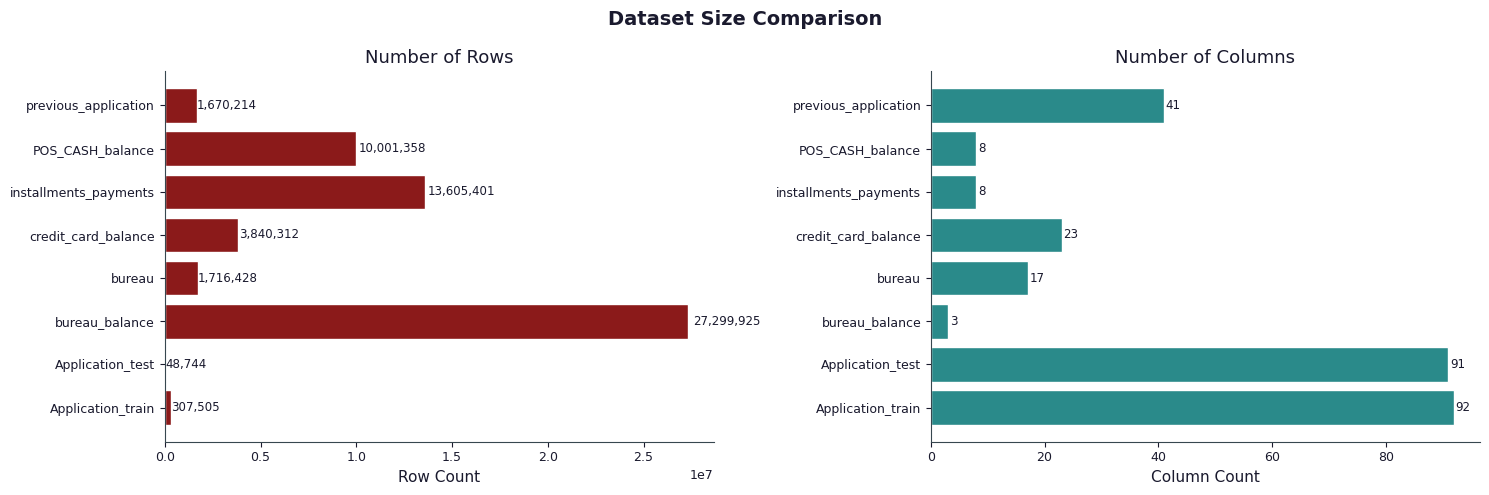

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Dataset Size Comparison", fontsize=14, fontweight="bold", color=NAVY)

names     = list(dfs.keys())
rows_vals = [t.shape[0] for t in dfs.values()]
cols_vals = [t.shape[1] for t in dfs.values()]

axes[0].barh(names, rows_vals, color=BLUE, edgecolor="white")
axes[0].set_title("Number of Rows"); axes[0].set_xlabel("Row Count")
for i, v in enumerate(rows_vals):
    axes[0].text(v * 1.01, i, f"{v:,}", va="center", fontsize=8.5, color=NAVY)

axes[1].barh(names, cols_vals, color=MINT, edgecolor="white")
axes[1].set_title("Number of Columns"); axes[1].set_xlabel("Column Count")
for i, v in enumerate(cols_vals):
    axes[1].text(v + 0.3, i, str(v), va="center", fontsize=8.5, color=NAVY)

plt.tight_layout()
save(fig, "01_dataset_overview.png")

## Target Variable Analysis

In [63]:
target_counts = train["TARGET"].value_counts()
target_pct    = train["TARGET"].value_counts(normalize=True) * 100

print(f"Non-Default (0): {target_counts[0]:,}  ({target_pct[0]:.2f}%)")
print(f"Default     (1): {target_counts[1]:,}  ({target_pct[1]:.2f}%)")
print(f"Imbalance ratio: {target_counts[0]/target_counts[1]:.1f} : 1")

Non-Default (0): 282,680  (91.93%)
Default     (1): 24,825  (8.07%)
Imbalance ratio: 11.4 : 1


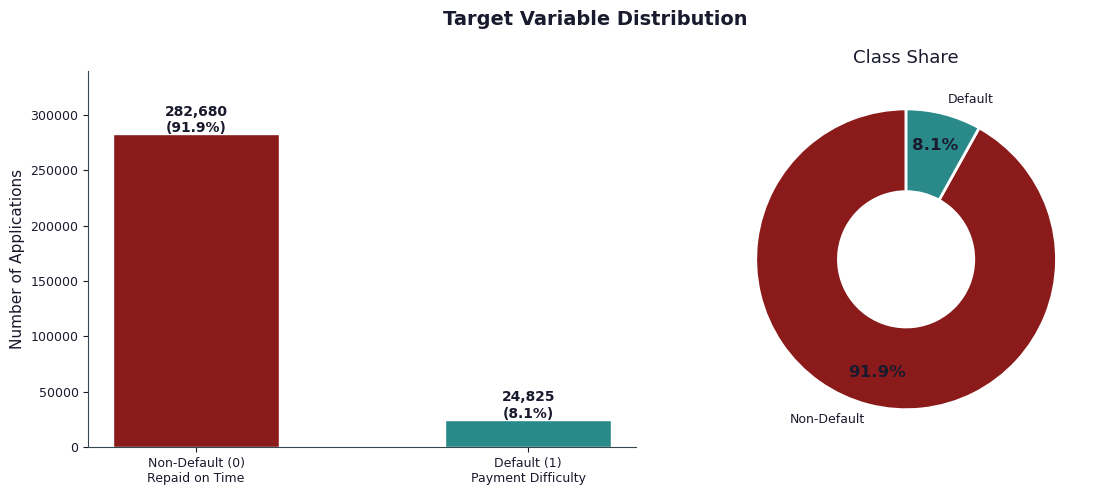

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold", color=NAVY)

labels = ["Non-Default (0)\nRepaid on Time", "Default (1)\nPayment Difficulty"]
bars = axes[0].bar(labels, target_counts.values, color=PALETTE_2, width=0.5, edgecolor="white")
axes[0].set_ylabel("Number of Applications")
for bar, cnt, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, cnt + 2000,
                 f"{cnt:,}\n({pct:.1f}%)", ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, target_counts.max() * 1.2)

wedges, texts, autotexts = axes[1].pie(
    target_counts.values, labels=["Non-Default", "Default"],
    autopct="%1.1f%%", colors=PALETTE_2, startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight("bold")
axes[1].set_title("Class Share")

plt.tight_layout()
save(fig, "02_target_distribution.png")

**Key Takeaway — Class Imbalance:**
- Only **~8.1%** of applicants defaulted. This is a highly imbalanced dataset.
- The 11.4:1 ratio means a model that always predicts "no default" gets 91.9% accuracy but is completely useless.
- For modelling: use **SMOTE**, class weights, or threshold tuning. Evaluate with **ROC-AUC or F1**, not accuracy.


## Demographic Analysis

Looking at gender, age, education and family status to see which groups default more.

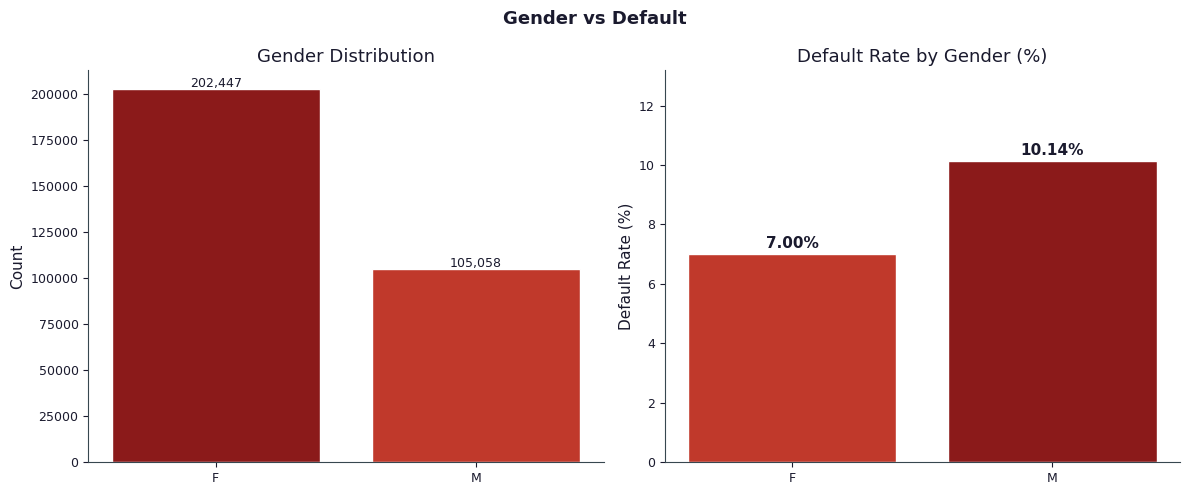

In [65]:
# Gender
valid = train[train["CODE_GENDER"] != "XNA"]
gd = valid.groupby("CODE_GENDER")["TARGET"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Gender vs Default", fontsize=13, fontweight="bold", color=NAVY)

gc = train["CODE_GENDER"].value_counts()
axes[0].bar(gc.index, gc.values, color=[BLUE, CORAL, GRAY], edgecolor="white")
axes[0].set_title("Gender Distribution"); axes[0].set_ylabel("Count")
for i, (g, v) in enumerate(gc.items()):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontsize=9)

axes[1].bar(gd.index, gd.values, color=[CORAL, BLUE], edgecolor="white")
axes[1].set_title("Default Rate by Gender (%)"); axes[1].set_ylabel("Default Rate (%)")
axes[1].set_ylim(0, gd.max() * 1.3)
for i, (g, v) in enumerate(gd.items()):
    axes[1].text(i, v + 0.2, f"{v:.2f}%", ha="center", fontweight="bold", fontsize=11)

plt.tight_layout()
save(fig, "05_gender.png")

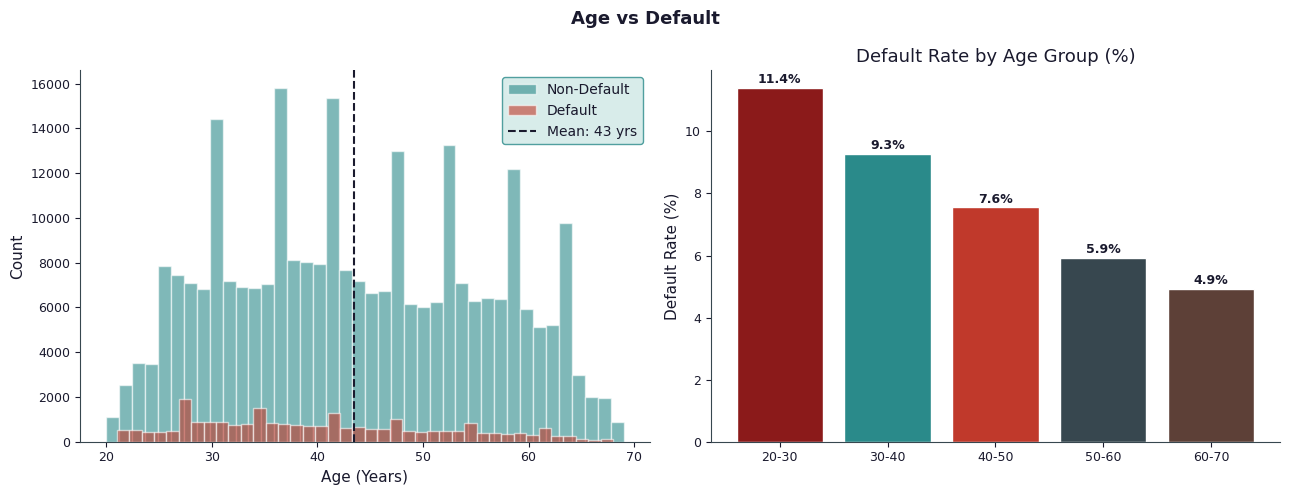

In [66]:
# Age
tables = [train,test]
for table in tables:
    table["AGE_YEARS"] = (-table["DAYS_BIRTH"] / 365).astype(int)
    table["AGE_GROUP"]  = pd.cut(table["AGE_YEARS"], bins=[20,30,40,50,60,70],
                            labels=["20-30","30-40","40-50","50-60","60-70"],
                            include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Age vs Default", fontsize=13, fontweight="bold", color=NAVY)

axes[0].hist(train[train["TARGET"]==0]["AGE_YEARS"], bins=40, alpha=0.6,
             color=MINT, label="Non-Default", edgecolor="white")
axes[0].hist(train[train["TARGET"]==1]["AGE_YEARS"], bins=40, alpha=0.6,
             color=CORAL, label="Default", edgecolor="white")
axes[0].set_xlabel("Age (Years)"); axes[0].set_ylabel("Count")
axes[0].axvline(train["AGE_YEARS"].mean(), color=NAVY, linestyle="--",
                label=f"Mean: {train['AGE_YEARS'].mean():.0f} yrs")
axes[0].legend()

age_default = train.groupby("AGE_GROUP", observed=True)["TARGET"].mean() * 100
axes[1].bar(age_default.index.astype(str), age_default.values,
            color=PALETTE_5, edgecolor="white")
axes[1].set_title("Default Rate by Age Group (%)"); axes[1].set_ylabel("Default Rate (%)")
for i, v in enumerate(age_default.values):
    axes[1].text(i, v + 0.15, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
save(fig, "06_age.png")

# Education & Family Status

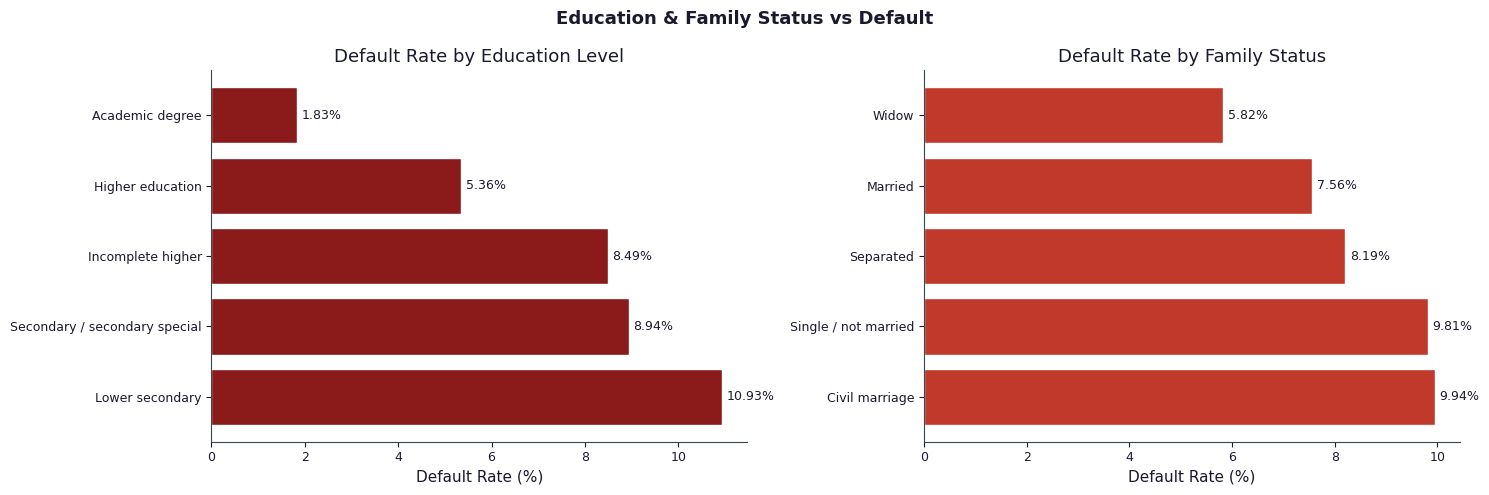

In [67]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Education & Family Status vs Default", fontsize=13, fontweight="bold", color=NAVY)

ed = train.groupby("NAME_EDUCATION_TYPE")["TARGET"].mean().sort_values(ascending=False)*100
axes[0].barh(ed.index, ed.values, color=BLUE, edgecolor="white")
axes[0].set_title("Default Rate by Education Level"); axes[0].set_xlabel("Default Rate (%)")
for i, v in enumerate(ed.values):
    axes[0].text(v + 0.1, i, f"{v:.2f}%", va="center", fontsize=9)

fs = train.groupby("NAME_FAMILY_STATUS")["TARGET"].mean().sort_values(ascending=False)*100
axes[1].barh(fs.index, fs.values, color=CORAL, edgecolor="white")
axes[1].set_title("Default Rate by Family Status"); axes[1].set_xlabel("Default Rate (%)")
for i, v in enumerate(fs.values):
    axes[1].text(v + 0.1, i, f"{v:.2f}%", va="center", fontsize=9)

plt.tight_layout()
save(fig, "07_education_family.png")

**Demographic Findings:**
- Males default at ~10%, females at ~7%. Meaningful gap.
- Younger applicants (20–30) default the most — likely lower income stability and less financial experience.
- Lower secondary education → highest default rate. Higher education → lowest.
- Single and civil marriage applicants show higher default rates than married ones.


## Financial Features

Looking at income, credit amount, and some engineered ratios.

In [68]:
financial_cols = ["AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE"]
display(train[financial_cols].describe().round(2))

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
count,307505.00,307505.00,307505.00,307505.00
mean,168796.66,599028.40,27108.55,538318.38
std,237124.85,402493.89,14493.56,369290.90
min,25650.00,45000.00,1615.50,40500.00
25%,112500.00,270000.00,16524.00,238500.00
50%,147150.00,513531.00,24903.00,450000.00
75%,202500.00,808650.00,34596.00,679500.00
max,117000000.00,4050000.00,258025.50,4050000.00


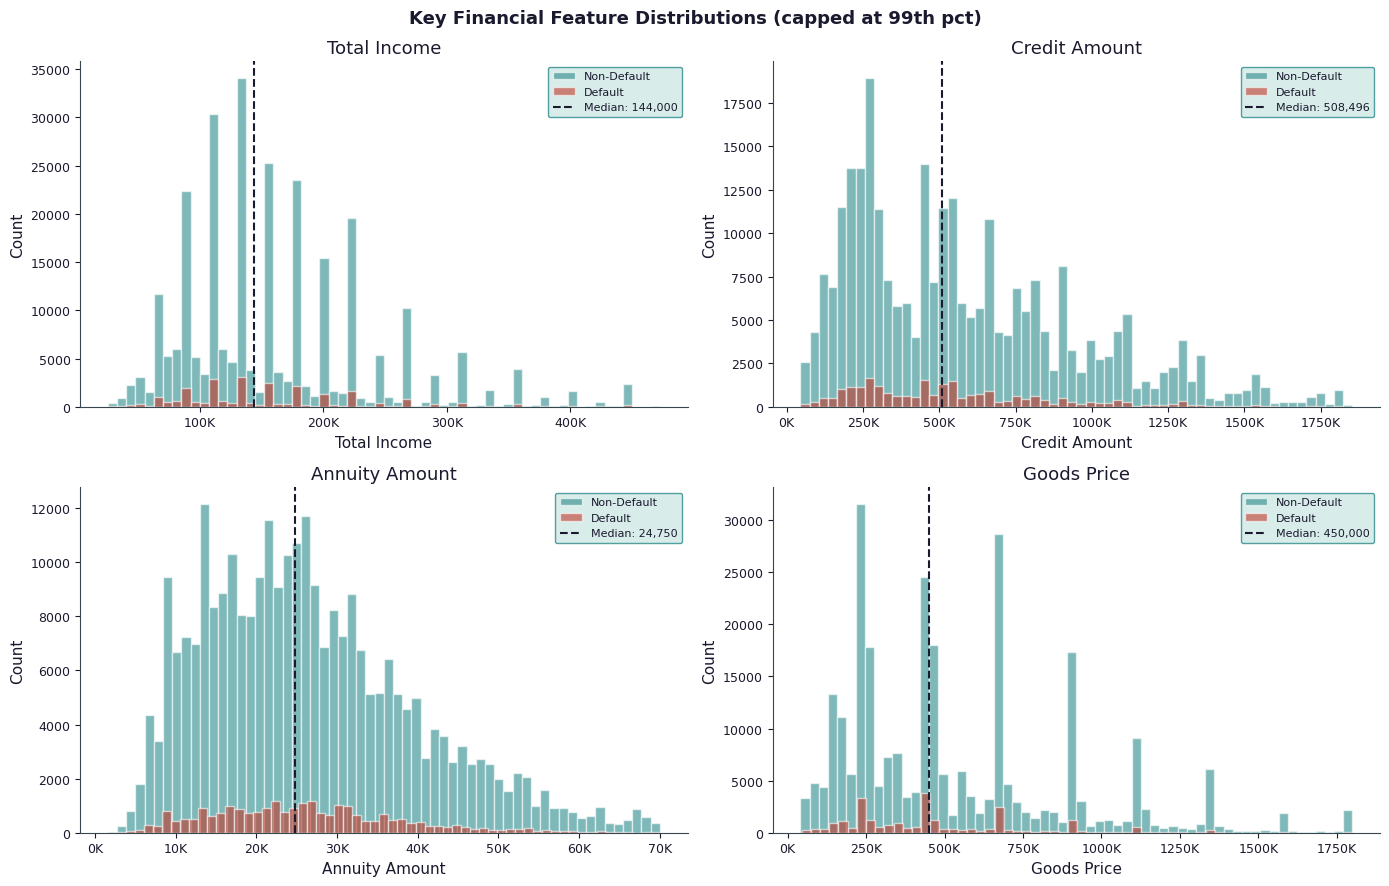

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Key Financial Feature Distributions (capped at 99th pct)",
             fontsize=13, fontweight="bold", color=NAVY)
titles = ["Total Income","Credit Amount","Annuity Amount","Goods Price"]

for ax, col, title in zip(axes.flatten(), financial_cols, titles):
    data = train[col].dropna()
    cap  = data.quantile(0.99)
    data = data[data <= cap]
    ax.hist(data[train["TARGET"]==0], bins=60, alpha=0.6, color=MINT, label="Non-Default", edgecolor="white")
    ax.hist(data[train["TARGET"]==1], bins=60, alpha=0.6, color=CORAL, label="Default", edgecolor="white")
    ax.set_title(title); ax.set_xlabel(title); ax.set_ylabel("Count")
    ax.axvline(data.median(), color=NAVY, linestyle="--", label=f"Median: {data.median():,.0f}")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

plt.tight_layout()
save(fig, "08_financial_distributions.png")

## External Credit Scores

`EXT_SOURCE_1/2/3` are normalized scores from external credit agencies. These turn out to be the strongest predictors in the entire dataset.

In [70]:
ext_scores = ["EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]

print("Correlation with TARGET and missing rates:")
for col in ext_scores:
    r    = train[col].corr(train["TARGET"])
    miss = train[col].isnull().mean() * 100
    print(f"  {col}:  r = {r:.4f}  |  Missing: {miss:.1f}%")

Correlation with TARGET and missing rates:
  EXT_SOURCE_1:  r = -0.1553  |  Missing: 56.4%
  EXT_SOURCE_2:  r = -0.1605  |  Missing: 0.2%
  EXT_SOURCE_3:  r = -0.1789  |  Missing: 19.8%


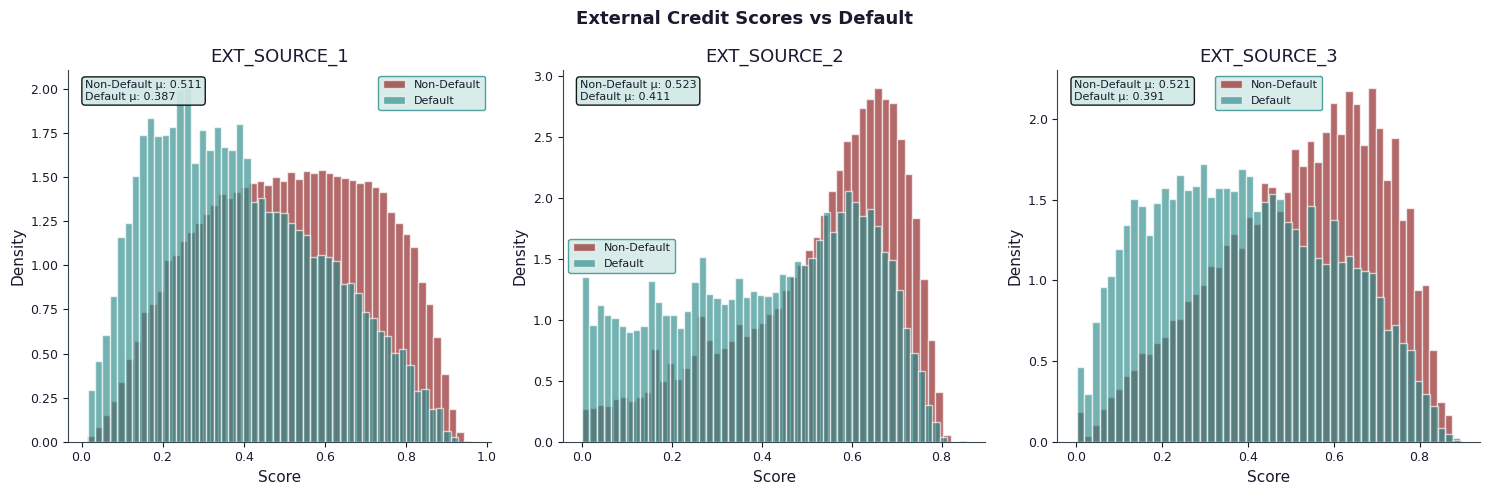

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("External Credit Scores vs Default", fontsize=13, fontweight="bold", color=NAVY)

for ax, col in zip(axes, ext_scores):
    for tv, color, label in zip([0,1], PALETTE_2, ["Non-Default","Default"]):
        data = train[train["TARGET"]==tv][col].dropna()
        ax.hist(data, bins=50, alpha=0.65, color=color, label=label,
                edgecolor="white", density=True)
    ax.set_title(col); ax.set_xlabel("Score"); ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    m0 = train[train["TARGET"]==0][col].mean()
    m1 = train[train["TARGET"]==1][col].mean()
    ax.text(0.04, 0.92, f"Non-Default μ: {m0:.3f}\nDefault μ: {m1:.3f}",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round", facecolor=LIGHT, alpha=0.9))

plt.tight_layout()
save(fig, "09_external_scores.png")

**External Score Insights:**
- All three scores are strongly negatively correlated with default — higher score = lower risk.
- `EXT_SOURCE_2` has the best coverage (~73% non-null) and strongest individual correlation (r ≈ −0.16).
- The distribution separation is very clear visually — these features should be top priority in any model.
- `EXT_SOURCE_1` missing 56% of values needs careful imputation (median or model-based).


## Correlation Analysis

Checking which numeric features correlate most with TARGET.

In [72]:
num_cols    = train.select_dtypes(include=np.number).columns.tolist()
corr_target = (train[num_cols].corr()["TARGET"]
               .drop("TARGET").sort_values(key=abs, ascending=False))

display(corr_target.head(20).to_frame("Pearson r").style
    .background_gradient(cmap="RdBu_r", vmin=-0.25, vmax=0.25)
    .format("{:.4f}"))

,Pearson r
EXT_SOURCE_3,-0.1789
EXT_SOURCE_2,-0.1605
EXT_SOURCE_1,-0.1553
DAYS_BIRTH,0.0782
AGE_YEARS,-0.0782
AGE,-0.0782
DAYS_EMPLOYED,0.0750
REGION_RATING_CLIENT_W_CITY,0.0609
REGION_RATING_CLIENT,0.0589
DAYS_LAST_PHONE_CHANGE,0.0552


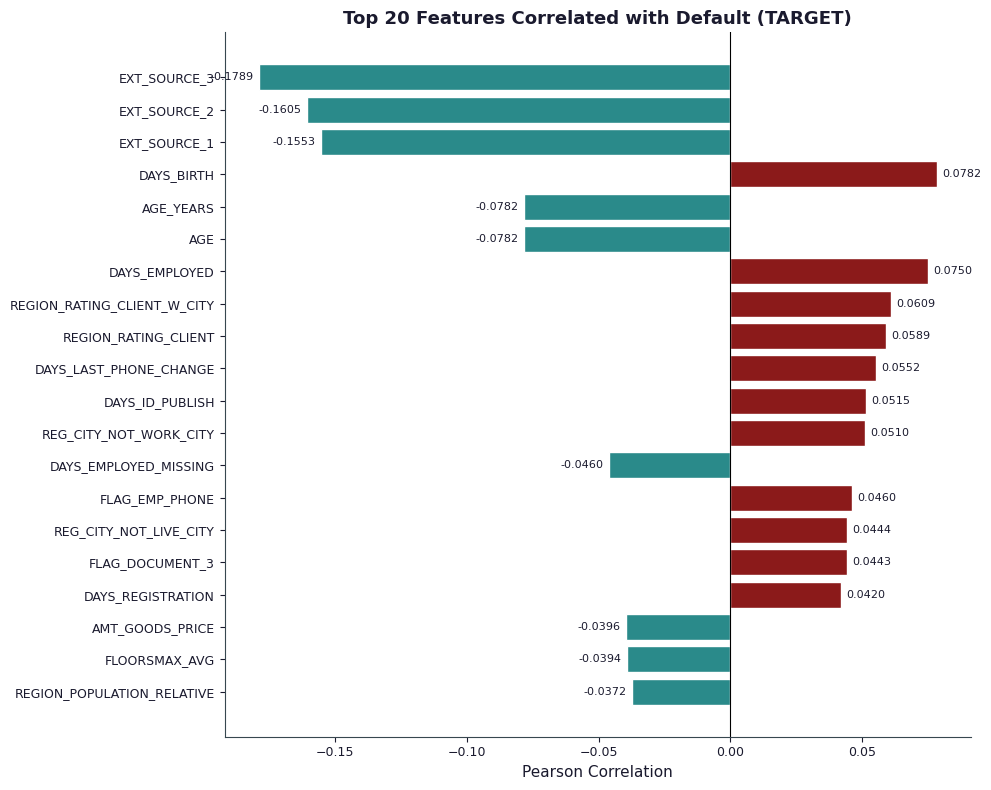

In [73]:
fig, ax = plt.subplots(figsize=(10, 8))
top20  = corr_target.head(20)
colors_c = [BLUE if v > 0 else MINT for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors_c[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 Features Correlated with Default (TARGET)",
             fontweight="bold", color=NAVY)
ax.set_xlabel("Pearson Correlation")
for i, v in enumerate(top20.values[::-1]):
    ax.text(v + (0.002 if v >= 0 else -0.002), i, f"{v:.4f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8)
plt.tight_layout()
save(fig, "10_correlation.png")

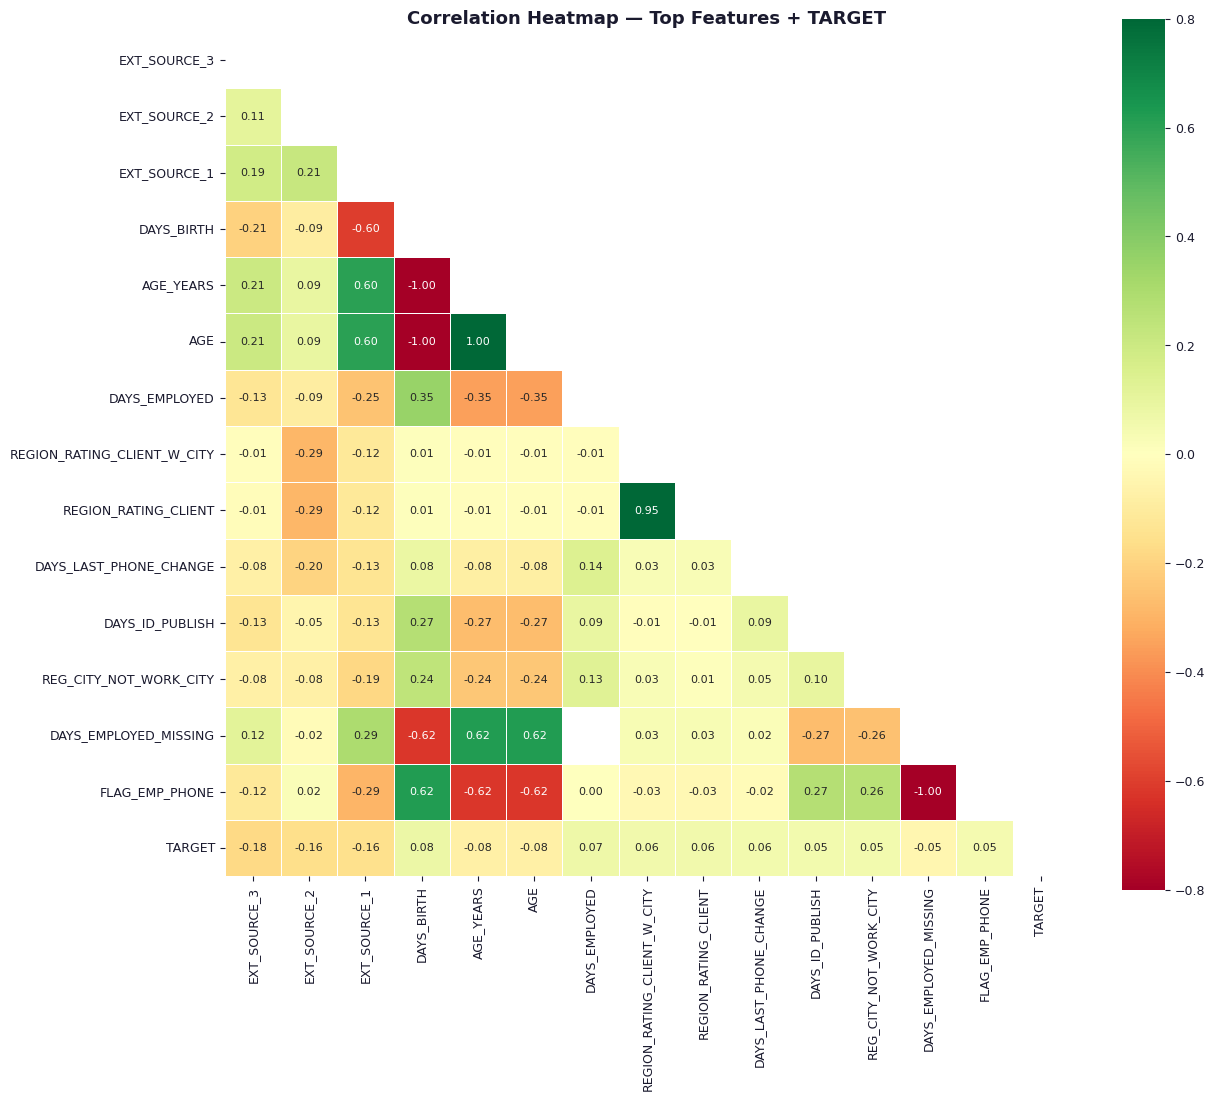

In [74]:
# Heatmap of top correlated features
top_feats   = corr_target.abs().head(14).index.tolist() + ["TARGET"]
corr_matrix = train[top_feats].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={"size": 8},
            vmin=-0.8, vmax=0.8)
ax.set_title("Correlation Heatmap — Top Features + TARGET",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
save(fig, "11_correlation_heatmap.png")

##  Employment & Occupation

Employment stability is a classic credit risk signal.

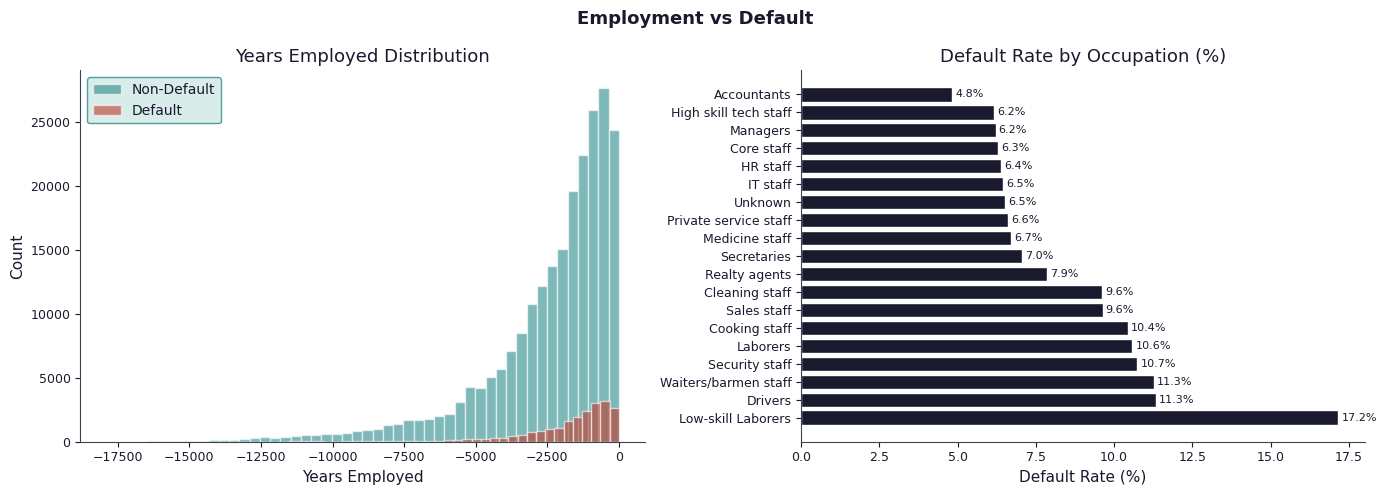

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Employment vs Default", fontsize=13, fontweight="bold", color=NAVY)

axes[0].hist(train[train["TARGET"]==0]["DAYS_EMPLOYED"].dropna(), bins=50,
             alpha=0.6, color=MINT, label="Non-Default", edgecolor="white")
axes[0].hist(train[train["TARGET"]==1]["DAYS_EMPLOYED"].dropna(), bins=50,
             alpha=0.6, color=CORAL, label="Default", edgecolor="white")
axes[0].set_title("Years Employed Distribution")
axes[0].set_xlabel("Years Employed"); axes[0].set_ylabel("Count")
axes[0].legend()

occ = train.groupby("OCCUPATION_TYPE")["TARGET"].mean().sort_values(ascending=False)*100
axes[1].barh(occ.index, occ.values, color=NAVY, edgecolor="white")
axes[1].set_title("Default Rate by Occupation (%)")
axes[1].set_xlabel("Default Rate (%)")
for i, v in enumerate(occ.values):
    axes[1].text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=8)

plt.tight_layout()
save(fig, "12_employment_occupation.png")

**Employment Findings:**
- Longer employment = lower default risk. Makes intuitive sense — job stability = financial stability.
- `DAYS_EMPLOYED = 365243` is a data encoding for unemployed (~18% of rows). Must be treated as NaN before modelling.
- Low-skill laborers have the highest default rate by occupation type.

##  Credit Bureau Analysis

The bureau table has external credit history for each applicant. I'll aggregate it per client.

In [76]:
print(f"Bureau shape         : {bureau.shape}")
print(f"Unique applicants    : {bureau['SK_ID_CURR'].nunique():,}")
print(f"Avg records/applicant: {len(bureau)/bureau['SK_ID_CURR'].nunique():.1f}")

print("\nCredit Active Status:")
display(bureau["CREDIT_ACTIVE"].value_counts().to_frame("Count").assign(
    Pct=lambda x: (x["Count"]/x["Count"].sum()*100).round(2)))

Bureau shape         : (1716428, 17)
Unique applicants    : 305,811
Avg records/applicant: 5.6

Credit Active Status:


,Count,Pct
CREDIT_ACTIVE,,
Closed,1079273,62.88
Active,630607,36.74
Sold,6527,0.38
Bad debt,21,0.00


In [77]:
bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_CREDIT_COUNT = ("SK_ID_BUREAU",           "count"),
    BUREAU_AVG_OVERDUE  = ("CREDIT_DAY_OVERDUE",     "mean"),
    BUREAU_MAX_OVERDUE  = ("AMT_CREDIT_MAX_OVERDUE", "max"),
    BUREAU_ACTIVE_COUNT = ("CREDIT_ACTIVE",          lambda x: (x=="Active").sum()),
    BUREAU_TOTAL_DEBT   = ("AMT_CREDIT_SUM_DEBT",    "sum"),
    BUREAU_TOTAL_CREDIT = ("AMT_CREDIT_SUM",         "sum"),
).reset_index()

app_bureau = train[["SK_ID_CURR","TARGET"]].merge(bureau_agg, on="SK_ID_CURR", how="left")

print("Bureau stats by default class:")
display(app_bureau.groupby("TARGET")[
    ["BUREAU_CREDIT_COUNT","BUREAU_AVG_OVERDUE","BUREAU_TOTAL_DEBT"]
].mean().round(3))

Bureau stats by default class:


,BUREAU_CREDIT_COUNT,BUREAU_AVG_OVERDUE,BUREAU_TOTAL_DEBT
TARGET,,,
0,5.56,0.97,637265.30
1,5.62,1.76,680978.73


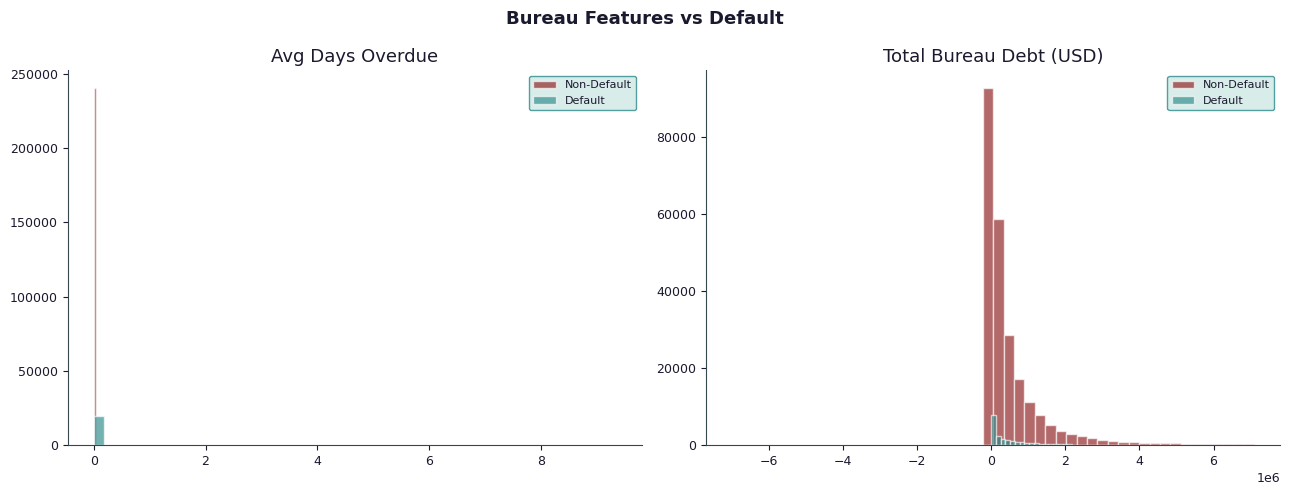

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Bureau Features vs Default", fontsize=13, fontweight="bold", color=NAVY)

for ax, col, title in zip(axes,
        ["BUREAU_AVG_OVERDUE","BUREAU_TOTAL_DEBT"],
        ["Avg Days Overdue","Total Bureau Debt (USD)"]):
    for tv, color, label in zip([0,1], PALETTE_2, ["Non-Default","Default"]):
        data = app_bureau[app_bureau["TARGET"]==tv][col].dropna()
        data = data[data <= data.quantile(0.99)]
        ax.hist(data, bins=50, alpha=0.65, color=color, label=label, edgecolor="white")
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
save(fig, "13_bureau_features.png")

**Bureau Insights:**
- Applicants with overdue days in bureau records default at much higher rates.
- Higher total bureau debt relative to income is a risk signal.
- Closed bureau credits are a neutral or mildly positive signal.


## Previous Application Analysis

Previous Home Credit loan applications per client — approval/refusal history matters.

In [79]:
prev_loan_counts = (bureau.groupby("SK_ID_CURR")["SK_ID_BUREAU"]
                    .count().reset_index()
                    .rename(columns={"SK_ID_BUREAU": "PREV_LOAN_COUNT"}))

prev_agg = previous.groupby("SK_ID_CURR").agg(
    PREV_APP_COUNT      = ("SK_ID_PREV",           "count"),
    PREV_APPROVED_COUNT = ("NAME_CONTRACT_STATUS", lambda x: (x=="Approved").sum()),
    PREV_REFUSED_COUNT  = ("NAME_CONTRACT_STATUS", lambda x: (x=="Refused").sum()),
    PREV_AVG_CREDIT     = ("AMT_CREDIT",           "mean"),
    PREV_AVG_ANNUITY    = ("AMT_ANNUITY",          "mean"),
).reset_index()

prev_agg["PREV_APPROVAL_RATE"] = (
    prev_agg["PREV_APPROVED_COUNT"] / prev_agg["PREV_APP_COUNT"] * 100).round(2)

app_prev = train[["SK_ID_CURR","TARGET"]].merge(prev_agg, on="SK_ID_CURR", how="left")

print("Previous approval rate by default class:")
display(app_prev.groupby("TARGET")["PREV_APPROVAL_RATE"].describe().round(2))

Previous approval rate by default class:


,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,267208.00,75.38,25.97,0.00,50.00,80.00,100.00,100.00
1,23845.00,69.31,28.41,0.00,50.00,66.67,100.00,100.00


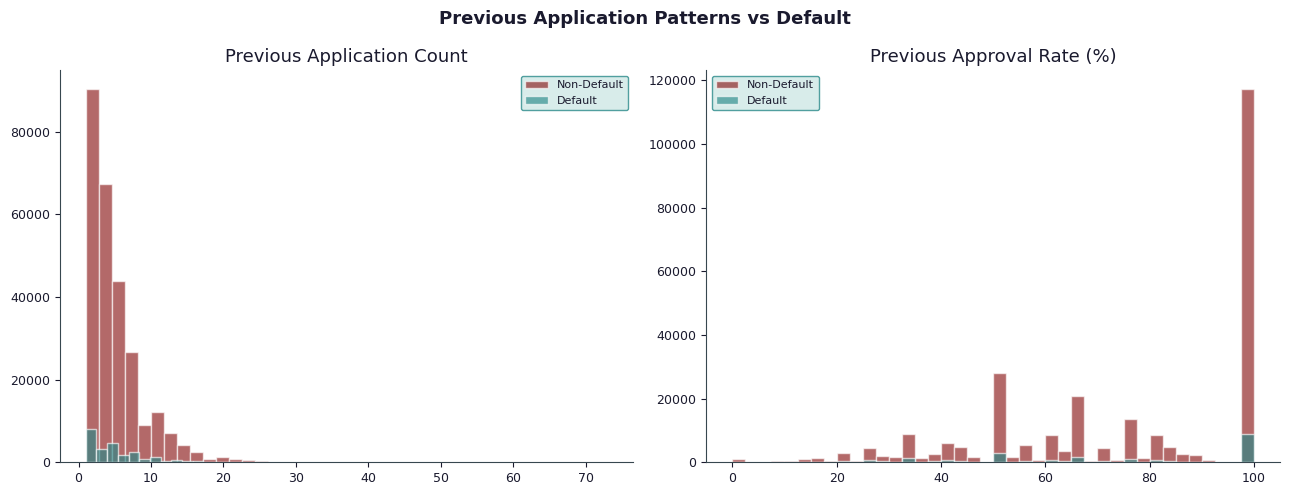

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Previous Application Patterns vs Default", fontsize=13, fontweight="bold", color=NAVY)

for ax, col, title in zip(axes,
        ["PREV_APP_COUNT","PREV_APPROVAL_RATE"],
        ["Previous Application Count","Previous Approval Rate (%)"]):
    for tv, color, label in zip([0,1], PALETTE_2, ["Non-Default","Default"]):
        data = app_prev[app_prev["TARGET"]==tv][col].dropna()
        ax.hist(data, bins=40, alpha=0.65, color=color, label=label, edgecolor="white")
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
save(fig, "14_prev_applications.png")

**Previous Application Insights:**
- Lower previous approval rates strongly predict current default.
- History of refused applications is a clear risk signal.
- The count of previous applications alone is a weaker predictor — what matters is the outcome pattern.


## POS Cash & Installment Payments

Actual repayment behaviour from past loans.

In [81]:
pos_agg = pos_cash.groupby("SK_ID_CURR").agg(
    POS_COUNT       = ("SK_ID_PREV", "count"),
    POS_AVG_DPD     = ("SK_DPD",    "mean"),
    POS_MAX_DPD     = ("SK_DPD",    "max"),
    POS_AVG_DPD_DEF = ("SK_DPD_DEF","mean"),
).reset_index()

inst_agg = installments.groupby("SK_ID_CURR").agg(
    INST_COUNT       = ("SK_ID_PREV",     "count"),
    INST_AVG_PAYMENT = ("AMT_PAYMENT",   "mean"),
    INST_AVG_AMOUNT  = ("AMT_INSTALMENT","mean"),
).reset_index()

app_pos  = train[["SK_ID_CURR","TARGET"]].merge(pos_agg,  on="SK_ID_CURR", how="left")
app_inst = train[["SK_ID_CURR","TARGET"]].merge(inst_agg, on="SK_ID_CURR", how="left")

print("POS avg DPD by default class:")
display(app_pos.groupby("TARGET")[["POS_AVG_DPD","POS_MAX_DPD"]].mean().round(3))

POS avg DPD by default class:


,POS_AVG_DPD,POS_MAX_DPD
TARGET,,
0,4.31,15.48
1,5.51,18.14


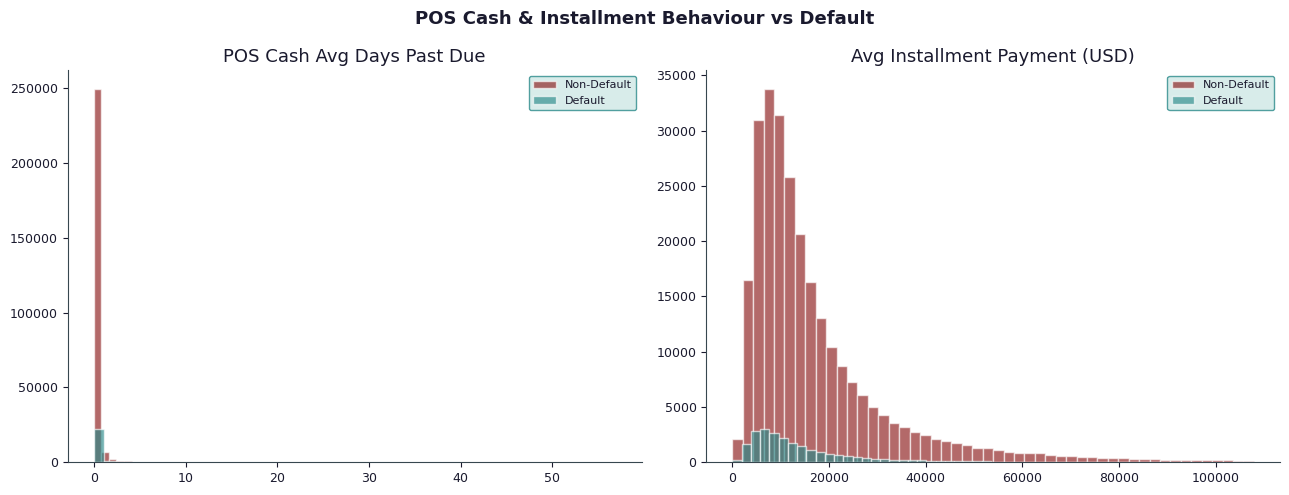

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("POS Cash & Installment Behaviour vs Default", fontsize=13, fontweight="bold", color=NAVY)

for ax, col, df_use, title in zip(axes,
        ["POS_AVG_DPD","INST_AVG_PAYMENT"],
        [app_pos, app_inst],
        ["POS Cash Avg Days Past Due","Avg Installment Payment (USD)"]):
    for tv, color, label in zip([0,1], PALETTE_2, ["Non-Default","Default"]):
        data = df_use[df_use["TARGET"]==tv][col].dropna()
        data = data[data <= data.quantile(0.99)]
        ax.hist(data, bins=50, alpha=0.65, color=color, label=label, edgecolor="white")
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
save(fig, "15_pos_installments.png")

## Credit Card Balance

Monthly snapshots of credit card activity.

In [83]:
cc_agg = credit_card.groupby("SK_ID_CURR").agg(
    CC_COUNT       = ("SK_ID_PREV",              "count"),
    CC_AVG_BALANCE = ("AMT_BALANCE",             "mean"),
    CC_MAX_BALANCE = ("AMT_BALANCE",             "max"),
    CC_AVG_LIMIT   = ("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    CC_AVG_DPD     = ("SK_DPD",                  "mean"),
).reset_index()

cc_agg["CC_UTILIZATION"] = (cc_agg["CC_AVG_BALANCE"] /
                             (cc_agg["CC_AVG_LIMIT"] + 1) * 100).round(2)

app_cc = train[["SK_ID_CURR","TARGET"]].merge(cc_agg, on="SK_ID_CURR", how="left")

print("Credit card utilization by default class:")
display(app_cc.groupby("TARGET")["CC_UTILIZATION"].describe().round(2))

Credit card utilization by default class:


,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,79371.00,1297.90,160321.72,-8.48,0.00,23.15,57.41,38099315.25
1,7534.00,266.13,12834.11,-8.48,9.06,49.34,79.79,1099350.00


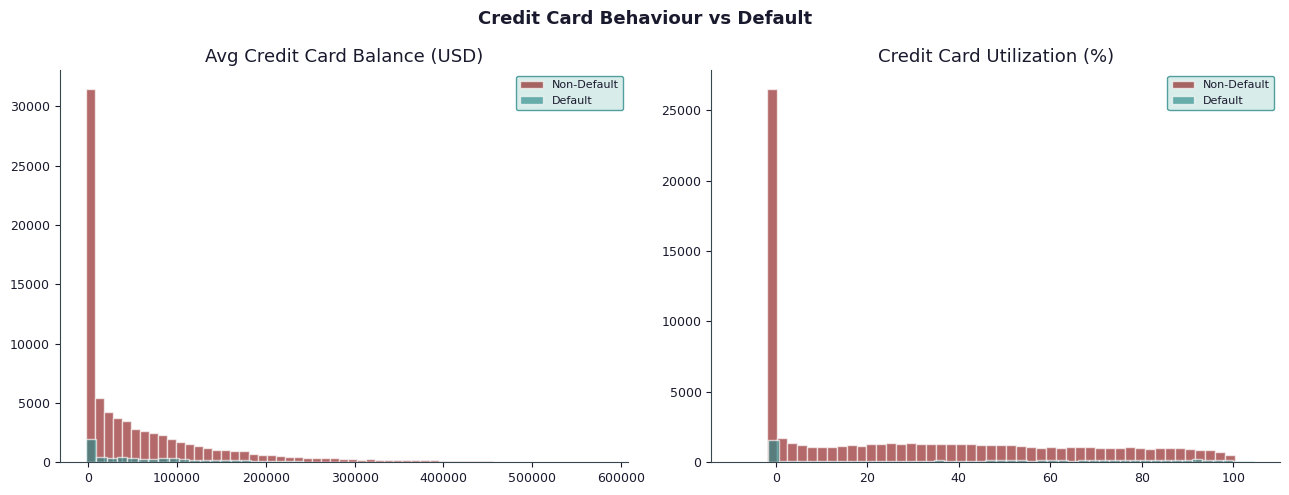

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Credit Card Behaviour vs Default", fontsize=13, fontweight="bold", color=NAVY)

for ax, col, title in zip(axes,
        ["CC_AVG_BALANCE","CC_UTILIZATION"],
        ["Avg Credit Card Balance (USD)","Credit Card Utilization (%)"]):
    for tv, color, label in zip([0,1], PALETTE_2, ["Non-Default","Default"]):
        data = app_cc[app_cc["TARGET"]==tv][col].dropna()
        data = data[data <= data.quantile(0.99)]
        ax.hist(data, bins=50, alpha=0.65, color=color, label=label, edgecolor="white")
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
save(fig, "16_credit_card.png")

**Credit Card Insights:**
- Higher utilization rates are associated with higher default probability — a classic credit risk signal.
- Defaulters carry higher average balances relative to their credit limits.


## Housing & Asset Ownership

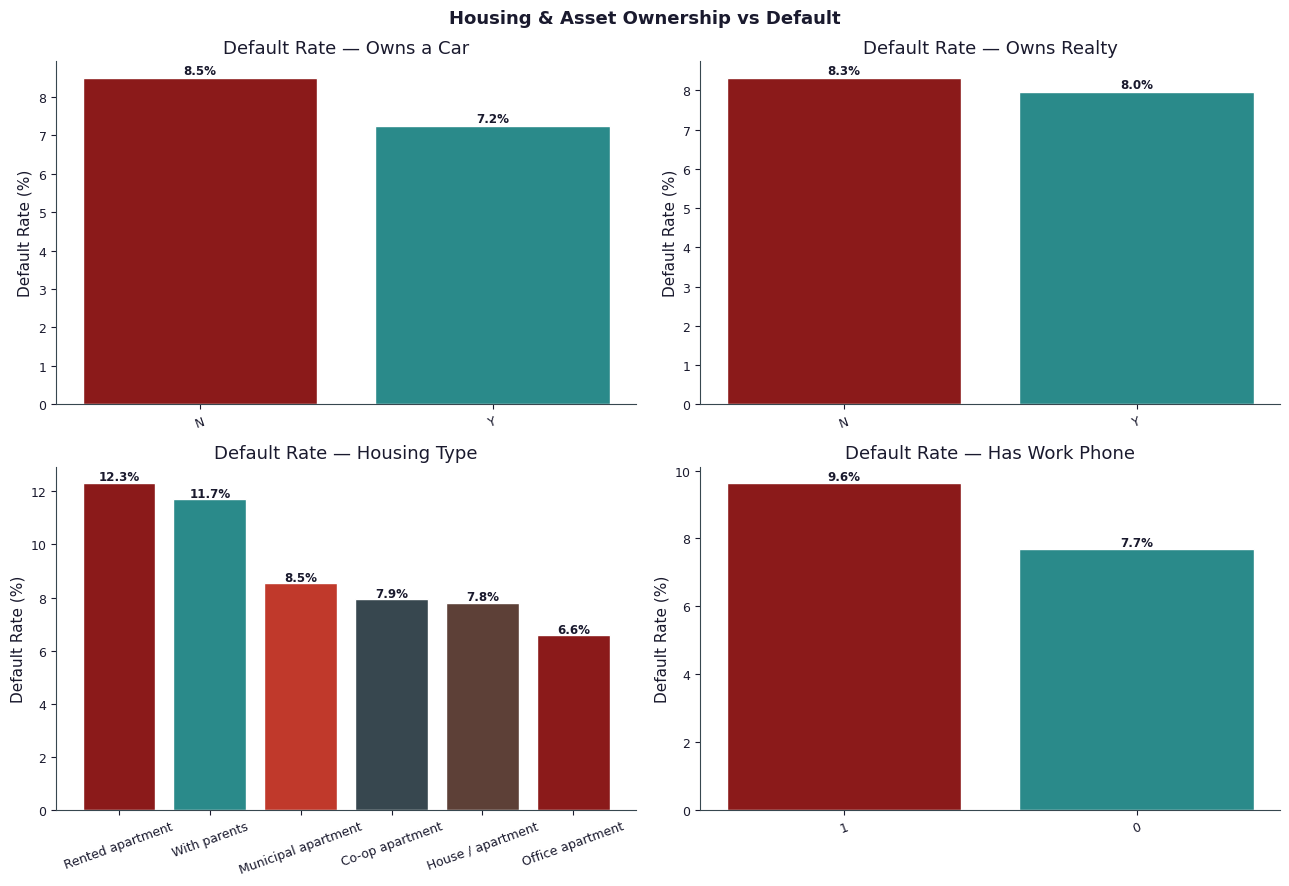

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Housing & Asset Ownership vs Default", fontsize=13, fontweight="bold", color=NAVY)

features = [("FLAG_OWN_CAR","Owns a Car"), ("FLAG_OWN_REALTY","Owns Realty"),
            ("NAME_HOUSING_TYPE","Housing Type"), ("FLAG_WORK_PHONE","Has Work Phone")]

for ax, (col, title) in zip(axes.flatten(), features):
    dbg = train.groupby(col)["TARGET"].mean().sort_values(ascending=False) * 100
    bars = ax.bar(dbg.index.astype(str), dbg.values,
                  color=PALETTE_5[:len(dbg)], edgecolor="white")
    ax.set_title(f"Default Rate — {title}")
    ax.set_ylabel("Default Rate (%)"); ax.tick_params(axis="x", rotation=20)
    for bar, v in zip(bars, dbg.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.1,
                f"{v:.1f}%", ha="center", fontsize=8.5, fontweight="bold")

plt.tight_layout()
save(fig, "17_housing_assets.png")

**Housing Insights:**
- Applicants without their own realty default more — less collateral, less financial stability.
- Renting or living in rented apartments is associated with higher risk.
- Car ownership shows a mild protective effect.


## Outlier Analysis

Checking for extreme values in financial columns.

In [86]:
cols_check = ["AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE"]

print(f"{'Column':<28} {'Q1':>12} {'Q3':>12} {'Outliers':>10} {'Outlier%':>10}")
print("-"*76)
for col in cols_check:
    Q1, Q3 = train[col].quantile(0.25), train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((train[col] < Q1 - 1.5*IQR) | (train[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col:<28} {Q1:>12,.0f} {Q3:>12,.0f} {outliers:>10,} {outliers/len(train)*100:>10.2f}%")

Column                                 Q1           Q3   Outliers   Outlier%
----------------------------------------------------------------------------
AMT_INCOME_TOTAL                  112,500      202,500     14,034       4.56%
AMT_CREDIT                        270,000      808,650      6,562       2.13%
AMT_ANNUITY                        16,524       34,596      7,504       2.44%
AMT_GOODS_PRICE                   238,500      679,500     14,728       4.79%


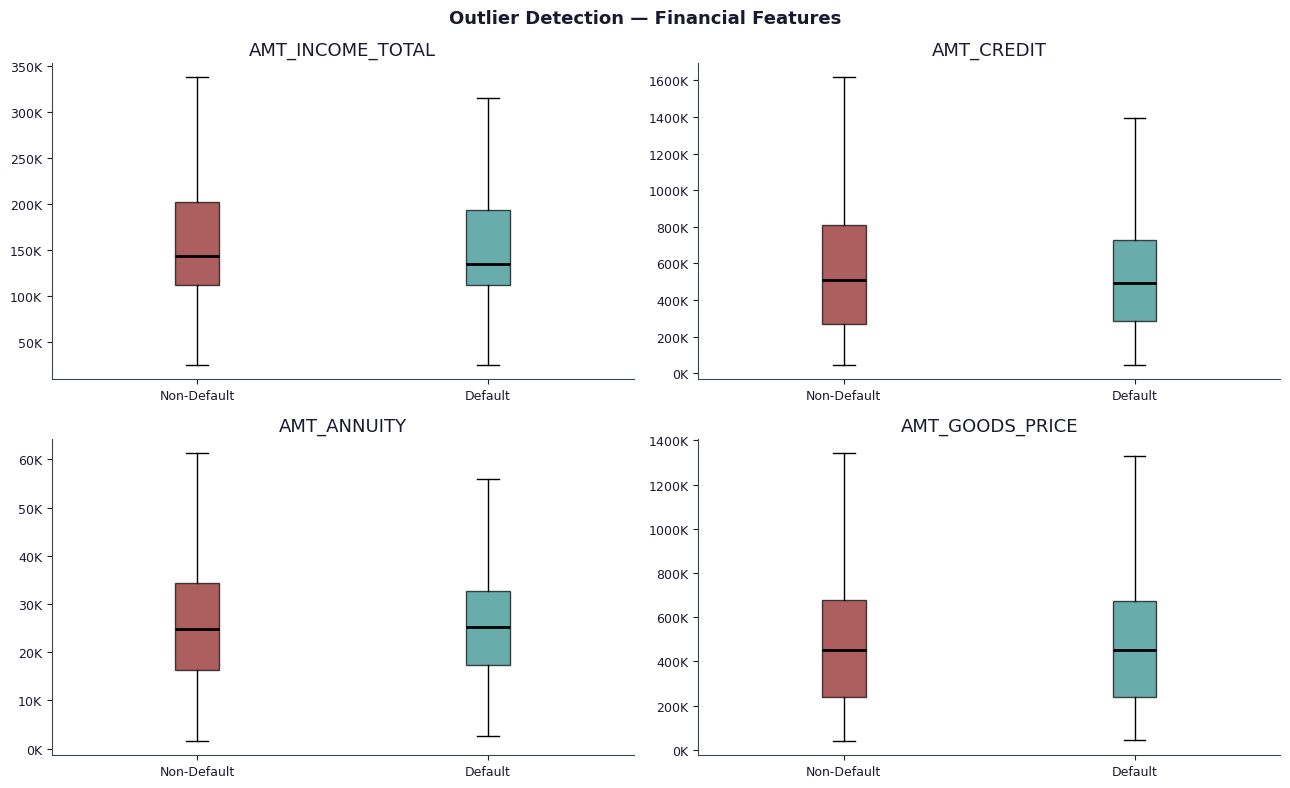

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Outlier Detection — Financial Features", fontsize=13, fontweight="bold", color=NAVY)

for ax, col in zip(axes.flatten(), cols_check):
    data = train[col].dropna()
    cap  = data.quantile(0.99)
    d0   = data[(data <= cap) & (train["TARGET"]==0)].values
    d1   = data[(data <= cap) & (train["TARGET"]==1)].values
    bp   = ax.boxplot([d0, d1], labels=["Non-Default","Default"],
                      patch_artist=True, showfliers=False,
                      medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], PALETTE_2):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(col)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

plt.tight_layout()
save(fig, "18_outliers.png")

**Outlier Findings:**
- `AMT_INCOME_TOTAL` has extreme outliers — some entries report incomes over $100M (likely data errors).
- ~10–15% of financial feature rows are outliers by IQR definition.
- **Recommended treatment before modelling:** Log-transform + cap at 99th percentile.


# dataset aggregation

bureau and bureau_balance

In [88]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [89]:
bureau_balance.SK_ID_BUREAU.duplicated().sum()

np.int64(26482530)

- C means closed,
- X means status unknown,
- 0 means no DPD,
- 1 means maximal did during month between 1-30,
- 2 means DPD 31-60,
- … 5 means DPD 120+ or sold or written off)",

In [90]:
bureau_balance.size

81899775

In [91]:
bb_agg= pd.get_dummies(bureau_balance,columns=['STATUS'],prefix='STATUS').astype(int)
new_cols = [col for col in bb_agg.columns if col.startswith('STATUS_')]
bb_agg

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS_0,STATUS_1,STATUS_2,STATUS_3,STATUS_4,STATUS_5,STATUS_C,STATUS_X
0,5715448,0,0,0,0,0,0,0,1,0
1,5715448,-1,0,0,0,0,0,0,1,0
2,5715448,-2,0,0,0,0,0,0,1,0
3,5715448,-3,0,0,0,0,0,0,1,0
4,5715448,-4,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
27299920,5041336,-47,0,0,0,0,0,0,0,1
27299921,5041336,-48,0,0,0,0,0,0,0,1
27299922,5041336,-49,0,0,0,0,0,0,0,1
27299923,5041336,-50,0,0,0,0,0,0,0,1


In [92]:
bb_aggregations = {'MONTHS_BALANCE': ['min', 'max', 'size']}

for col in new_cols:
    bb_aggregations[col] = ['mean']
bb_agg=bb_agg.groupby('SK_ID_BUREAU').agg(bb_aggregations)

In [93]:
bb_agg

MONTHS_BALANCE          STATUS_0 STATUS_1 STATUS_2 STATUS_3 STATUS_4 STATUS_5 STATUS_C STATUS_X
                        min max size     mean     mean     mean     mean     mean     mean     mean     mean
SK_ID_BUREAU                                                                                                
5001709                 -96   0   97     0.00     0.00     0.00     0.00     0.00     0.00     0.89     0.11
5001710                 -82   0   83     0.06     0.00     0.00     0.00     0.00     0.00     0.58     0.36
5001711                  -3   0    4     0.75     0.00     0.00     0.00     0.00     0.00     0.00     0.25
5001712                 -18   0   19     0.53     0.00     0.00     0.00     0.00     0.00     0.47     0.00
5001713                 -21   0   22     0.00     0.00     0.00     0.00     0.00     0.00     0.00     1.00
...                     ...  ..  ...      ...      ...      ...      ...      ...      ...      ...      ...
6842884                 -47   0   48     0.19     0.00     0.00     0.00     0.00     0.00     0.42     0.40
6842885                 -23   0   24     0.50     0.00     0.00     0.00     0.00     0.50     0.00     0.00
6842886                 -32   0   33     0.24     0.00     0.00     0.00     0.00     0.00     0.76     0.00
6842887                 -36   0   37     0.16     0.00     0.00     0.00     0.00     0.00     0.84     0.00
6842888                 -61   0   62     0.15     0.02     0.00     0.00     0.00     0.00     0.84     0.00

[817395 rows x 11 columns]

In [94]:
bb_agg.columns = pd.Index([e[0]+'_'+e[1].upper()for e in bb_agg.columns.tolist()])
bb_agg

,MONTHS_BALANCE_MIN,MONTHS_BALANCE_MAX,MONTHS_BALANCE_SIZE,STATUS_0_MEAN,STATUS_1_MEAN,STATUS_2_MEAN,STATUS_3_MEAN,STATUS_4_MEAN,STATUS_5_MEAN,STATUS_C_MEAN,STATUS_X_MEAN
SK_ID_BUREAU,,,,,,,,,,,
5001709,-96,0,97,0.00,0.00,0.00,0.00,0.00,0.00,0.89,0.11
5001710,-82,0,83,0.06,0.00,0.00,0.00,0.00,0.00,0.58,0.36
5001711,-3,0,4,0.75,0.00,0.00,0.00,0.00,0.00,0.00,0.25
5001712,-18,0,19,0.53,0.00,0.00,0.00,0.00,0.00,0.47,0.00
5001713,-21,0,22,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...
6842884,-47,0,48,0.19,0.00,0.00,0.00,0.00,0.00,0.42,0.40
6842885,-23,0,24,0.50,0.00,0.00,0.00,0.00,0.50,0.00,0.00
6842886,-32,0,33,0.24,0.00,0.00,0.00,0.00,0.00,0.76,0.00


In [95]:
# Find the first month when the credit is closed!
closed = bureau_balance[bureau_balance.STATUS == "C"]
closed = closed.groupby("SK_ID_BUREAU").MONTHS_BALANCE.min().reset_index().rename({"MONTHS_BALANCE":"MONTHS_BALANCE_FIRST_C"}, axis = 1)
closed["MONTHS_BALANCE_FIRST_C"] = np.abs(closed["MONTHS_BALANCE_FIRST_C"])
closed

,SK_ID_BUREAU,MONTHS_BALANCE_FIRST_C
0,5001709,85
1,5001710,47
2,5001712,8
3,5001716,38
4,5001717,4
...,...,...
449599,6842883,34
449600,6842884,19
449601,6842886,24
449602,6842887,30


In [96]:
# Status Sum
bb_agg["STATUS_C0_MEAN_SUM"] = bb_agg[["STATUS_C_MEAN", "STATUS_0_MEAN"]].sum(axis = 1)
bb_agg["STATUS_12_MEAN_SUM"] = bb_agg[["STATUS_1_MEAN", "STATUS_2_MEAN"]].sum(axis = 1)
bb_agg["STATUS_345_MEAN_SUM"] = bb_agg[["STATUS_3_MEAN", "STATUS_4_MEAN", "STATUS_5_MEAN"]].sum(axis = 1)
bb_agg["STATUS_12345_MEAN_SUM"] = bb_agg[["STATUS_1_MEAN", "STATUS_2_MEAN", "STATUS_3_MEAN", "STATUS_4_MEAN", "STATUS_5_MEAN"]].sum(axis = 1)
bb_agg = pd.merge(bb_agg, closed, how = "left", on = "SK_ID_BUREAU")
bb_agg["MONTHS_BALANCE_CLOSED_DIF"] = np.abs(bb_agg.MONTHS_BALANCE_MIN) - bb_agg.MONTHS_BALANCE_FIRST_C
bb_agg

,SK_ID_BUREAU,MONTHS_BALANCE_MIN,MONTHS_BALANCE_MAX,MONTHS_BALANCE_SIZE,STATUS_0_MEAN,STATUS_1_MEAN,STATUS_2_MEAN,STATUS_3_MEAN,STATUS_4_MEAN,STATUS_5_MEAN,STATUS_C_MEAN,STATUS_X_MEAN,STATUS_C0_MEAN_SUM,STATUS_12_MEAN_SUM,STATUS_345_MEAN_SUM,STATUS_12345_MEAN_SUM,MONTHS_BALANCE_FIRST_C,MONTHS_BALANCE_CLOSED_DIF
0,5001709,-96,0,97,0.00,0.00,0.00,0.00,0.00,0.00,0.89,0.11,0.89,0.00,0.00,0.00,85.00,11.00
1,5001710,-82,0,83,0.06,0.00,0.00,0.00,0.00,0.00,0.58,0.36,0.64,0.00,0.00,0.00,47.00,35.00
2,5001711,-3,0,4,0.75,0.00,0.00,0.00,0.00,0.00,0.00,0.25,0.75,0.00,0.00,0.00,NaN,NaN
3,5001712,-18,0,19,0.53,0.00,0.00,0.00,0.00,0.00,0.47,0.00,1.00,0.00,0.00,0.00,8.00,10.00
4,5001713,-21,0,22,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817390,6842884,-47,0,48,0.19,0.00,0.00,0.00,0.00,0.00,0.42,0.40,0.60,0.00,0.00,0.00,19.00,28.00
817391,6842885,-23,0,24,0.50,0.00,0.00,0.00,0.00,0.50,0.00,0.00,0.50,0.00,0.50,0.50,NaN,NaN
817392,6842886,-32,0,33,0.24,0.00,0.00,0.00,0.00,0.00,0.76,0.00,1.00,0.00,0.00,0.00,24.00,8.00
817393,6842887,-36,0,37,0.16,0.00,0.00,0.00,0.00,0.00,0.84,0.00,1.00,0.00,0.00,0.00,30.00,6.00


In [97]:
bb_agg[bb_agg['SK_ID_BUREAU']==5001709]

,SK_ID_BUREAU,MONTHS_BALANCE_MIN,MONTHS_BALANCE_MAX,MONTHS_BALANCE_SIZE,STATUS_0_MEAN,STATUS_1_MEAN,STATUS_2_MEAN,STATUS_3_MEAN,STATUS_4_MEAN,STATUS_5_MEAN,STATUS_C_MEAN,STATUS_X_MEAN,STATUS_C0_MEAN_SUM,STATUS_12_MEAN_SUM,STATUS_345_MEAN_SUM,STATUS_12345_MEAN_SUM,MONTHS_BALANCE_FIRST_C,MONTHS_BALANCE_CLOSED_DIF
0,5001709,-96,0,97,0.00,0.00,0.00,0.00,0.00,0.00,0.89,0.11,0.89,0.00,0.00,0.00,85.00,11.00


### merge bureau_balance and bureau

In [98]:
bureau= pd.merge(bureau,bb_agg,how='left',on= 'SK_ID_BUREAU')
print(bureau.shape,"\n")
bureau.head()

(1716428, 34) 



,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,HAS_CLOSED_DATE,MONTHS_BALANCE_MIN,MONTHS_BALANCE_MAX,MONTHS_BALANCE_SIZE,STATUS_0_MEAN,STATUS_1_MEAN,STATUS_2_MEAN,STATUS_3_MEAN,STATUS_4_MEAN,STATUS_5_MEAN,STATUS_C_MEAN,STATUS_X_MEAN,STATUS_C0_MEAN_SUM,STATUS_12_MEAN_SUM,STATUS_345_MEAN_SUM,STATUS_12345_MEAN_SUM,MONTHS_BALANCE_FIRST_C,MONTHS_BALANCE_CLOSED_DIF
0,215354,5714462,Closed,currency 1,-497,0,-153.00,-153.00,0.00,0,91323.00,0.00,0.00,0.00,Consumer credit,-131,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.00,0.00,0.00,0,225000.00,171342.00,0.00,0.00,Credit card,-20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.00,0.00,0.00,0,464323.50,0.00,0.00,0.00,Consumer credit,-16,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,-330.00,0.00,0.00,0,90000.00,0.00,0.00,0.00,Credit card,-16,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.00,0.00,77674.50,0,2700000.00,0.00,0.00,0.00,Consumer credit,-21,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
def missing_values(data,plot=False):
    df= pd.DataFrame(
        {"Num_Missing":data.isnull().sum(),\
         "Missing_Ratio":data.isnull().sum()/data.shape[0]}
    ).sort_values(by="Num_Missing",ascending=False)
    df["DataTypes"]=data[df.index].dtypes.values
    df=df[df.Num_Missing>0].reset_index().rename({"index":"Feature"},axis=1)

    print("Number of variables include Missing Values:",df.shape[0],"\n")

    if df[df.Missing_Ratio==1.0].shape[0]>1:
        print("Full Missing Variables:",df[df.Missing_Ratio ==1.0].Feature.tolist())
        data.drop(df[df.Missing_Ratio==1.0].Feature.to_list(),axis=1,inplace=True)

        print("Full Missing variables are deleted!","\n")
    if plot:
        plt.figure(figsize=(25,8))
        p=sns.barplot(df.Feature,df.Missing_Ratio)
        for rotate in p.get_xticklabels():
            rotate.set_rotation(45)
        plt.show()
    print(df,"\n")
        


In [102]:
missing_values(bureau,plot=False)

Number of variables include Missing Values: 17 

                      Feature  Num_Missing  Missing_Ratio DataTypes
0   MONTHS_BALANCE_CLOSED_DIF      1299036           0.76   float64
1      MONTHS_BALANCE_FIRST_C      1299036           0.76   float64
2         STATUS_345_MEAN_SUM       942074           0.55   float64
3               STATUS_0_MEAN       942074           0.55   float64
4          MONTHS_BALANCE_MIN       942074           0.55   float64
5       STATUS_12345_MEAN_SUM       942074           0.55   float64
6               STATUS_X_MEAN       942074           0.55   float64
7               STATUS_C_MEAN       942074           0.55   float64
8          STATUS_C0_MEAN_SUM       942074           0.55   float64
9          STATUS_12_MEAN_SUM       942074           0.55   float64
10              STATUS_1_MEAN       942074           0.55   float64
11         MONTHS_BALANCE_MAX       942074           0.55   float64
12              STATUS_3_MEAN       942074           0.55   float64